# 5주차 실습 (1) — Numerical Stability

> **부동소수점은 새는 추상화(leaky abstraction)다. 학습 중에 반드시 당신을 문다. 그리고 미리 보이지 않는다.**

- **Type:** Build · **Language:** Python · **Time:** ~120분
- **선수 지식:** Phase 1 Lesson 01~04 (선형대수 직관, 벡터·행렬 연산, 미분, 확률)
- 원문: <https://aiengineeringfromscratch.com/lesson.html?path=phases/01-math-foundations/13-numerical-stability>

## 🎯 학습 목표 (Learning Objectives)

1. **max 빼기 트릭**으로 수치적으로 안정한 **softmax**와 **log-sum-exp**를 구현한다.
2. 부동소수점 연산에서 **오버플로 · 언더플로 · 파괴적 상쇄**를 식별한다.
3. **중심 차분(centered difference)** 수치 미분으로 해석적 그래디언트를 검증한다.
4. 학습에서 **왜 float16보다 bfloat16이 선호되는지**, **loss scaling**이 어떻게 그래디언트 언더플로를 막는지 설명한다.

---

## 📖 이 노트북을 읽는 법

> 🧸 **비유** (초등학생용) → 📐 **개념** (정확한 규칙) → 💻 **코드** (직접 증명) → 🏭 **실무** (어디에 쓰나)

| # | 주제 |
| --- | --- |
| 0 | 문제 상황 — 3시간 학습 뒤 loss = NaN |
| 1 | IEEE 754 — 컴퓨터가 실수를 저장하는 법 |
| 2 | `0.1 + 0.2 != 0.3` — 이진 반복소수 |
| 3 | 파괴적 상쇄 — 뺄셈 한 번에 유효숫자가 사라진다 |
| 4 | 오버플로 · 언더플로 — `exp()`와 `log()`의 절벽 |
| 5 | 🔑 log-sum-exp 트릭 — 이 레슨의 핵심 벽돌 |
| 6 | 🔨 Build It 1~4 — 안정 softmax · logsumexp · cross-entropy |
| 7 | 🔨 Build It 5 — 그래디언트 체킹 (`h`는 왜 1e-5인가) |
| 8 | 혼합 정밀도 · float16 vs bfloat16 · loss scaling |
| 9 | 그래디언트 클리핑 (value vs norm) |
| 10 | 정규화 층은 사실 수치 안정 장치다 |
| 11 | 🏭 Use It — 흔한 수치 버그 7개 처방전 · PyTorch 대조 |
| 12 | 📝 연습문제 5개 (풀이 포함) |
| 13 | 📚 용어 사전 · Ship It · 더 읽을거리 |

## 0️⃣ 문제 상황 (The Problem)

모델을 3시간 돌렸다. 그리고 loss가 `NaN`이 된다. print를 찍어 본다.

```
step 9000 : logits ok    loss 2.31
step 9001 : logits inf   loss inf
step 9002 : grads nan    loss nan   <- 학습 사망
```

또는 — 학습은 끝까지 되는데 **정확도가 논문보다 2% 낮다.** 구조도 같고 하이퍼파라미터도 같고 데이터도 같다.
차이는 하나: 논문은 float32였고 나는 float16을 아무 스케일링 없이 썼다.
**32비트어치 반올림 오차가 조용히 정확도를 갉아먹은 것이다.**

또는 — cross-entropy를 밑바닥부터 구현했다. 작은 logit에서는 잘 된다.
logit이 100을 넘자 `inf`가 나온다. `exp(100)`이 float32 범위를 넘어 softmax가 오버플로했다.
모든 ML 프레임워크는 **두 줄짜리 트릭**으로 이걸 해결한다. 나는 그 트릭이 존재하는 줄 몰랐을 뿐이다.

> **수치 안정성은 이론적 관심사가 아니다. 학습이 성공하느냐 조용히 실패하느냐의 차이다.**
> 당신이 앞으로 디버깅할 진지한 ML 버그는 결국 대부분 부동소수점으로 귀결된다.

---

### 🧭 잠깐 — 이 노트북의 지도

이 레슨은 사실 **하나의 벽돌**로 되어 있다.

```
      exp()는 위로 터지고,  log()는 아래로 터진다
                    ↓
      "가장 큰 값을 먼저 빼라"  =  log-sum-exp 트릭
                    ↓
   안정 softmax → 안정 cross-entropy → log_softmax → 어텐션
```

나머지(정밀도, 상쇄, 클리핑, 혼합 정밀도)는 **"터지는 지점을 미리 알고 피하는 법"** 이다.

In [13]:
# ── 공통 설정 (그림의 한글 폰트 포함) ──────────────────────────────
import math
import struct

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

np.set_printoptions(precision=6, suppress=False)

available = {f.name for f in fm.fontManager.ttflist}
for cand in ["Apple SD Gothic Neo", "AppleGothic", "NanumGothic",
             "NanumBarunGothicOTF", "Malgun Gothic", "Noto Sans CJK KR"]:
    if cand in available:
        # DejaVu를 앞에 두는 이유: 로그축 눈금의 유니코드 마이너스(U+2212)를 한글 폰트가
        # 렌더링하지 못해 경고가 뜬다. 한글은 폴백 체인의 두 번째 폰트가 처리한다.
        matplotlib.rcParams["font.family"] = ["DejaVu Sans", cand]
        break
matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams["mathtext.fontset"] = "dejavusans"
matplotlib.rcParams["figure.dpi"] = 110
print("그림 폰트(폴백 순서):", matplotlib.rcParams["font.family"])

그림 폰트(폴백 순서): ['DejaVu Sans', 'Apple SD Gothic Neo']


In [14]:
# 이 레슨이 왜 필요한지 30초 데모 — 같은 코드가 정밀도에 따라 다른 지점에서 죽는다
def softmax_naive(z):
    exps = [math.exp(v) for v in z]      # <- 여기서 터진다
    total = sum(exps)
    return [e / total for e in exps]

def softmax_naive_f32(z):
    # 실제 학습이 도는 정밀도(float32)에서 같은 코드를 돌려 본다
    with np.errstate(over="ignore", invalid="ignore"):
        e = np.exp(np.array(z, dtype=np.float32))
        return (e / e.sum()).tolist()

for logits in ([100.0, 101.0, 102.0], [800.0, 801.0, 802.0]):
    print(f"logits {logits}")
    try:
        print("  파이썬 float(=float64) naive:", [f"{p:.6f}" for p in softmax_naive(logits)])
    except OverflowError as e:
        print("  파이썬 float(=float64) naive: OverflowError -", e)
    print("  float32 naive               :", softmax_naive_f32(logits))

print(f"\n두 정밀도의 exp 한계선")
print(f"  float32: exp(88.7)={math.exp(88.7):.3e} 까지  (최대값 {np.finfo(np.float32).max:.3e})")
print(f"  float64: exp(709) ={math.exp(709):.3e} 까지  (최대값 {np.finfo(np.float64).max:.3e})")
print("=> 경계 위치만 다를 뿐 문제는 똑같다. 그리고 학습은 float32/float16에서 돈다.")

logits [100.0, 101.0, 102.0]
  파이썬 float(=float64) naive: ['0.090031', '0.244728', '0.665241']
  float32 naive               : [nan, nan, nan]
logits [800.0, 801.0, 802.0]
  파이썬 float(=float64) naive: OverflowError - math range error
  float32 naive               : [nan, nan, nan]

두 정밀도의 exp 한계선
  float32: exp(88.7)=3.326e+38 까지  (최대값 3.403e+38)
  float64: exp(709) =8.218e+307 까지  (최대값 1.798e+308)
=> 경계 위치만 다를 뿐 문제는 똑같다. 그리고 학습은 float32/float16에서 돈다.


## 1️⃣ IEEE 754 — 컴퓨터가 실수를 저장하는 법

### 🧸 비유 — 유효숫자 7자리짜리 공학용 계산기

부동소수점은 **"유효숫자 몇 자리 + 소수점을 몇 칸 옮길지"** 로 숫자를 적는 방식이다.

```
  1.234567 × 10^25
  └──┬───┘   └─┬─┘
  가수(mantissa)  지수(exponent)
   = 정밀도        = 범위
```

- **가수(mantissa)** 를 늘리면 → **자릿수(정밀도)** 가 좋아진다. 1.0000001과 1.0000002를 구분할 수 있다.
- **지수(exponent)** 를 늘리면 → **표현 범위**가 넓어진다. 아주 크거나 아주 작은 수를 담을 수 있다.

**16비트라는 예산을 정밀도와 범위 중 어디에 쓸 것인가** — 이게 float16 vs bfloat16 논쟁의 전부다.

### 📐 개념

```
float32 레이아웃 (총 32비트)
[1 부호] [8 지수] [23 가수]

값 = (-1)^부호 × 2^(지수-127) × 1.가수
```

| 포맷 | 비트 | 지수 | 가수 | 십진 유효자리 | 대략 범위 |
| --- | --- | --- | --- | --- | --- |
| float64 | 64 | 11 | 52 | ~15–16 | ±1.8e308 |
| float32 | 32 | 8 | 23 | ~7–8 | ±3.4e38 |
| float16 | 16 | 5 | **10** | ~3–4 | **±65,504** |
| bfloat16 | 16 | **8** | 7 | ~2–3 | ±3.4e38 |

- **float32**: 십진 7자리쯤. 그 뒤는 전부 반올림 잡음이다.
- **float16**: 십진 3자리. 최대값이 **65,504** — logit·활성값·그래디언트가 예사로 넘는 크기다.
- **bfloat16**: float32와 **똑같은 8비트 지수**(같은 범위) + 가수 7비트. 정밀도를 버리고 범위를 샀다.

> 💡 딥러닝 학습에서는 **정밀도보다 범위가 중요**하다. 그래서 보통 bfloat16이 이긴다. (8절에서 실측)

In [15]:
# 각 포맷의 실제 한계를 직접 확인
print(f"{'포맷':<10}{'최대값':>14}{'최소 정규값':>15}{'머신 엡실론':>15}{'유효자리':>10}")
print("-" * 66)
for name, dt in [("float64", np.float64), ("float32", np.float32), ("float16", np.float16)]:
    fi = np.finfo(dt)
    print(f"{name:<10}{float(fi.max):>14.4g}{float(fi.tiny):>15.4g}"
          f"{float(fi.eps):>15.4g}{fi.precision:>10}")

# 머신 엡실론의 의미: 1.0 + eps != 1.0 인 가장 작은 eps
eps32 = np.finfo(np.float32).eps
one = np.float32(1.0)
print(f"\nfloat32 eps = {eps32:.6e}")
print(f"  1.0 + eps      != 1.0 ?  {one + np.float32(eps32) != one}")
print(f"  1.0 + eps/2    != 1.0 ?  {one + np.float32(eps32 / 2) != one}  <- 이보다 작으면 그냥 사라진다")

포맷                   최대값         최소 정규값         머신 엡실론      유효자리
------------------------------------------------------------------
float64       1.798e+308     2.225e-308       2.22e-16        15
float32        3.403e+38      1.175e-38      1.192e-07         6
float16         6.55e+04      6.104e-05      0.0009766         3

float32 eps = 1.192093e-07
  1.0 + eps      != 1.0 ?  True
  1.0 + eps/2    != 1.0 ?  False  <- 이보다 작으면 그냥 사라진다


In [16]:
# float32 비트를 직접 뜯어보기 — 부호 / 지수 / 가수
def float32_bits(x):
    as_int = struct.unpack("I", struct.pack("f", x))[0]
    bits = format(as_int, "032b")
    return bits[0], bits[1:9], bits[9:]

print(f"{'값':>12}  {'부호':>4} {'지수(8)':>10} {'가수(23)':>25}")
print("-" * 58)
for v in [1.0, 2.0, 0.5, 0.1, -3.75]:
    s, e, m = float32_bits(v)
    exp_unbiased = int(e, 2) - 127
    print(f"{v:>12}  {s:>4} {e:>10} {m:>25}   2^{exp_unbiased}")

# 0.1은 왜 정확히 저장되지 않는가 — 가수 비트가 반복 패턴에서 잘렸다
print("\n0.1의 이진 표현 = 0.0001100110011001100... (무한 반복)")
print(f"float32로 저장된 실제 값: {np.float32(0.1):.20f}")
print(f"float64로 저장된 실제 값: {0.1:.20f}")

           값    부호      지수(8)                    가수(23)
----------------------------------------------------------
         1.0     0   01111111   00000000000000000000000   2^0
         2.0     0   10000000   00000000000000000000000   2^1
         0.5     0   01111110   00000000000000000000000   2^-1
         0.1     0   01111011   10011001100110011001101   2^-4
       -3.75     1   10000000   11100000000000000000000   2^1

0.1의 이진 표현 = 0.0001100110011001100... (무한 반복)
float32로 저장된 실제 값: 0.10000000149011611938
float64로 저장된 실제 값: 0.10000000000000000555


### 🖼️ 그림 1 — 16비트라는 예산을 어디에 쓸 것인가 (비트 레이아웃)

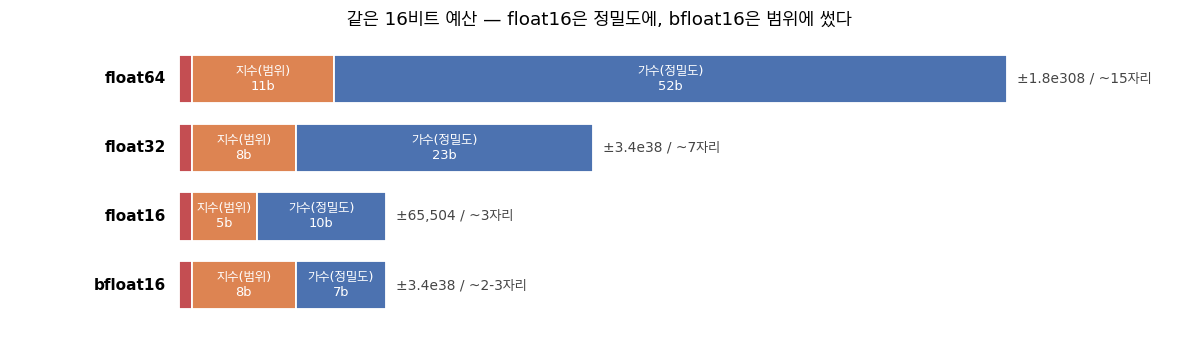

In [17]:
layouts = [
    ("float64", 1, 11, 52, "±1.8e308 / ~15자리"),
    ("float32", 1, 8, 23, "±3.4e38 / ~7자리"),
    ("float16", 1, 5, 10, "±65,504 / ~3자리"),
    ("bfloat16", 1, 8, 7, "±3.4e38 / ~2-3자리"),
]
fig, ax = plt.subplots(figsize=(11, 3.2))
colors = {"부호": "#c44e52", "지수(범위)": "#dd8452", "가수(정밀도)": "#4c72b0"}
for row, (name, s, e, m, note) in enumerate(layouts):
    y = len(layouts) - row - 1
    total = s + e + m
    x = 0
    for label, width in [("부호", s), ("지수(범위)", e), ("가수(정밀도)", m)]:
        ax.add_patch(plt.Rectangle((x, y), width, 0.7, fc=colors[label], ec="white", lw=1.2))
        if width >= 4:
            ax.text(x + width / 2, y + 0.35, f"{label}\n{width}b", ha="center", va="center",
                    color="white", fontsize=8.5)
        x += width
    ax.text(-1.0, y + 0.35, name, ha="right", va="center", fontsize=10, weight="bold")
    ax.text(total + 0.8, y + 0.35, note, ha="left", va="center", fontsize=9, color="#444")

ax.set_xlim(-13, 78)
ax.set_ylim(-0.3, len(layouts))
ax.axis("off")
ax.set_title("같은 16비트 예산 — float16은 정밀도에, bfloat16은 범위에 썼다", fontsize=12)
plt.tight_layout()
plt.show()

### 🖼️ 그림 2 — 정밀도의 실체: 숫자가 커질수록 '표현 가능한 간격'이 벌어진다

/var/folders/9w/m7__0lhd16xcy6bzy6qwytpc0000gn/T/ipykernel_75001/152889407.py:4: RuntimeWarning: overflow encountered in cast
  ulp16 = np.array([np.spacing(np.float16(m)) for m in mags], dtype=np.float64)
/var/folders/9w/m7__0lhd16xcy6bzy6qwytpc0000gn/T/ipykernel_75001/152889407.py:4: RuntimeWarning: invalid value encountered in spacing
  ulp16 = np.array([np.spacing(np.float16(m)) for m in mags], dtype=np.float64)


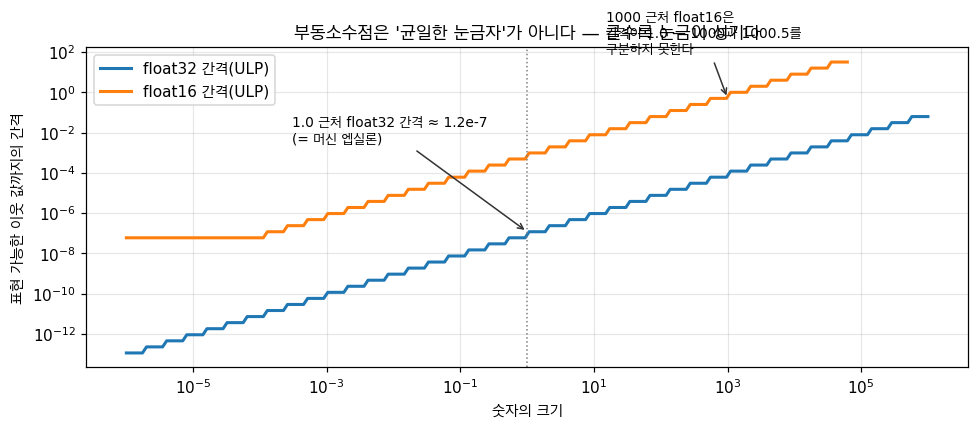

In [18]:
# ULP(Unit in the Last Place) = 그 크기 주변에서 표현 가능한 두 수 사이의 간격
mags = np.logspace(-6, 6, 200)
ulp32 = np.array([np.spacing(np.float32(m)) for m in mags], dtype=np.float64)
ulp16 = np.array([np.spacing(np.float16(m)) for m in mags], dtype=np.float64)

fig, ax = plt.subplots(figsize=(9, 4))
ax.loglog(mags, ulp32, label="float32 간격(ULP)", lw=2)
ax.loglog(mags, ulp16, label="float16 간격(ULP)", lw=2)
ax.axvline(1.0, color="gray", ls=":", lw=1)
ax.annotate("1.0 근처 float32 간격 ≈ 1.2e-7\n(= 머신 엡실론)", xy=(1.0, np.spacing(np.float32(1.0))),
            xytext=(3e-4, 3e-3), fontsize=9,
            arrowprops=dict(arrowstyle="->", color="#333"))
ax.annotate("1000 근처 float16은\n간격이 1.0 — 1000과 1000.5를\n구분하지 못한다", xy=(1000, np.spacing(np.float16(1000.0))),
            xytext=(1.5e1, 8e1), fontsize=9,
            arrowprops=dict(arrowstyle="->", color="#333"))
ax.set_xlabel("숫자의 크기")
ax.set_ylabel("표현 가능한 이웃 값까지의 간격")
ax.set_title("부동소수점은 '균일한 눈금자'가 아니다 — 클수록 눈금이 성기다")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

## 2️⃣ `0.1 + 0.2 != 0.3` — 이진 반복소수

### 🧸 비유 — 십진수로 1/3을 적어 보기

십진법에서 `1/3 = 0.3333...` 은 아무리 적어도 끝나지 않는다. 어딘가에서 자를 수밖에 없다.
**이진법에서는 0.1이 바로 그런 수다.**

```
0.1(십진) = 0.000110011001100110011...(이진, 무한 반복)
```

float64는 가수 52비트에서 자른다. 저장된 실제 값은 `0.1000000000000000055511...` 이다.

### 📐 그래서 ML에서 뭐가 문제인가

1. `if loss < threshold` 같은 비교가 **경계에서 틀린 답**을 준다.
2. **작은 값을 수천 번 누적**(그래디언트 업데이트)하면 참값에서 서서히 표류한다.
3. 재현성 테스트를 `==` 로 하면 실패한다.

> ✅ **처방: float를 `==` 로 비교하지 마라.** `abs(a-b) < eps` 또는 `math.isclose()` / `np.allclose()`.

In [19]:
print(f"0.1 + 0.2         = {0.1 + 0.2:.20f}")
print(f"0.3               = {0.3:.20f}")
print(f"0.1 + 0.2 == 0.3  ? {0.1 + 0.2 == 0.3}")
print(f"차이               = {(0.1 + 0.2) - 0.3:.3e}")
print(f"math.isclose      ? {math.isclose(0.1 + 0.2, 0.3)}   <- 올바른 비교법")

# 누적 오차: 0.1을 100만 번 더하면?
total = 0.0
for _ in range(1_000_000):
    total += 0.1
print(f"\n0.1을 100만 번 더함 = {total:.6f}   (참값 100000.0)")
print(f"누적 오차          = {total - 100000.0:.6e}")

# Kahan 보상 합산 — 잃어버린 하위 비트를 따로 들고 다닌다
def kahan_sum(values):
    total, compensation = 0.0, 0.0
    for v in values:
        y = v - compensation           # 지난번에 잃은 만큼 미리 보정
        t = total + y
        compensation = (t - total) - y  # 이번에 잃은 하위 비트를 회수
        total = t
    return total

vals = [0.1] * 1_000_000
print(f"Kahan 합산         = {kahan_sum(vals):.6f}   오차 = {kahan_sum(vals) - 100000.0:.3e}")

0.1 + 0.2         = 0.30000000000000004441
0.3               = 0.29999999999999998890
0.1 + 0.2 == 0.3  ? False
차이               = 5.551e-17
math.isclose      ? True   <- 올바른 비교법

0.1을 100만 번 더함 = 100000.000001   (참값 100000.0)
누적 오차          = 1.332883e-06
Kahan 합산         = 100000.000000   오차 = 0.000e+00


## 3️⃣ 파괴적 상쇄 (Catastrophic Cancellation)

### 🧸 비유 — 몸무게로 반지 무게 재기

체중계에 올라가 78.4kg, 반지를 끼고 다시 올라가 78.4kg.
**"78.4 − 78.4 = 0kg"** — 반지 무게를 이렇게 재면 안 된다.
두 큰 수의 차로 작은 수를 구하면, **유효숫자가 통째로 상쇄되고 반올림 잡음만 남는다.**

### 📐 개념

```
a = 1.0000001   (float32 저장값 1.00000011920929)
b = 1.0000000   (float32 저장값 1.00000000000000)

참 차이   : 0.0000001
계산 결과 : 0.00000011920929
상대 오차 : 19.2%   ← 뺄셈 딱 한 번에!
```

ML에서 이게 터지는 지점:

- 평균이 큰 데이터의 분산을 `E[x²] − E[x]²` 로 계산할 때
- 거의 같은 로그 확률을 뺄 때
- 유한 차분에서 `h`를 너무 작게 잡을 때 (7절에서 그래프로 확인)

> ✅ **처방:** 큰 수끼리 빼지 않도록 식을 다시 쓴다. 분산은 **Welford 알고리즘**을 쓰거나 **데이터를 먼저 중심화**한다.
> 로그 확률은 **끝까지 로그 공간에서** 계산한다.

In [20]:
def variance_naive(xs):
    # E[x^2] - E[x]^2 — 수학적으로는 맞지만 수치적으로 위험하다
    n = len(xs)
    mean_sq = sum(np.float32(x) * np.float32(x) for x in xs) / n
    mean = sum(np.float32(x) for x in xs) / n
    return float(mean_sq - mean * mean)

def variance_welford(xs):
    # Welford 온라인 알고리즘 — 큰 수끼리의 뺄셈이 없다
    n, mean, m2 = 0, np.float32(0.0), np.float32(0.0)
    for x in xs:
        n += 1
        x = np.float32(x)
        delta = x - mean          # 이 차이는 작다 -> 상쇄가 일어나지 않는다
        mean += delta / n
        m2 += delta * (x - mean)
    return float(m2 / n)

data = [1_000_000.0, 1_000_001.0, 1_000_002.0]
true_var = 2.0 / 3.0
print(f"데이터: {data}   참 분산 = {true_var:.6f}")
print(f"naive   (E[x²]-E[x]²) = {variance_naive(data):>12.6f}   오차 {abs(variance_naive(data)-true_var)/true_var*100:>8.2f}%")
print(f"Welford               = {variance_welford(data):>12.6f}   오차 {abs(variance_welford(data)-true_var)/true_var*100:>8.2f}%")
print(f"중심화 후 naive        = {variance_naive([x - 1_000_000.0 for x in data]):>12.6f}   <- 평균만 빼도 살아난다")

데이터: [1000000.0, 1000001.0, 1000002.0]   참 분산 = 0.666667
naive   (E[x²]-E[x]²) =  5673.666626   오차 850949.99%
Welford               =     0.666667   오차     0.00%
중심화 후 naive        =     0.666667   <- 평균만 빼도 살아난다


### 🖼️ 그림 3 — 평균이 커질수록 naive 분산은 언제 무너지는가

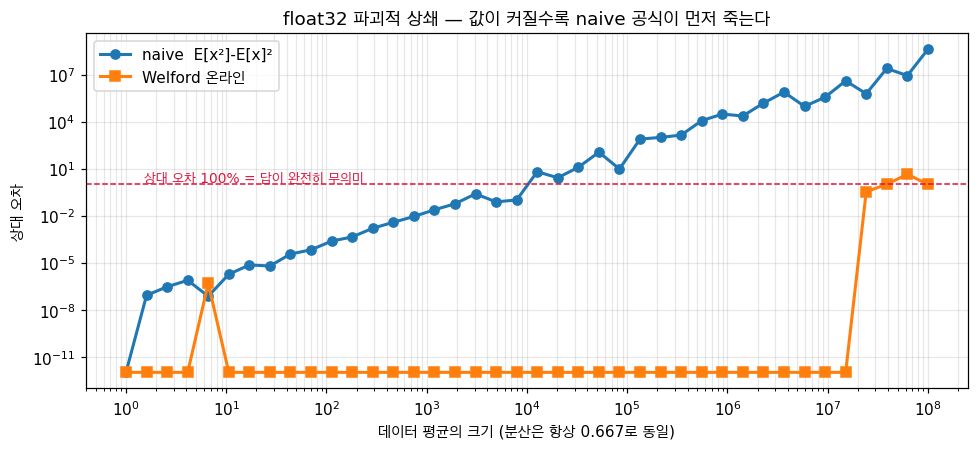

In [21]:
offsets = np.logspace(0, 8, 40)
err_naive, err_welford = [], []
for off in offsets:
    d = [off + 0.0, off + 1.0, off + 2.0]
    err_naive.append(abs(variance_naive(d) - true_var) / true_var)
    err_welford.append(abs(variance_welford(d) - true_var) / true_var)

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.loglog(offsets, np.maximum(err_naive, 1e-12), "o-", label="naive  E[x²]-E[x]²", lw=2)
ax.loglog(offsets, np.maximum(err_welford, 1e-12), "s-", label="Welford 온라인", lw=2)
ax.axhline(1.0, color="crimson", ls="--", lw=1)
ax.text(1.5, 1.3, "상대 오차 100% = 답이 완전히 무의미", color="crimson", fontsize=9)
ax.set_xlabel("데이터 평균의 크기 (분산은 항상 0.667로 동일)")
ax.set_ylabel("상대 오차")
ax.set_title("float32 파괴적 상쇄 — 값이 커질수록 naive 공식이 먼저 죽는다")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

## 4️⃣ 오버플로 · 언더플로 — `exp()`와 `log()`의 절벽

### 📐 개념

- **오버플로**: 결과가 표현 가능한 최대값보다 크다 → `inf`
- **언더플로**: 결과가 0에 너무 가깝다 → `0.0`

```
float32 경계
  최대값             : 3.4028235e+38
  최소 정규값        : 1.175e-38
  최소 비정규값      : 1.401e-45
  > 3.4e38  -> inf
  < 1.4e-45 -> 0.0
```

**`exp()`는 ML에서 오버플로의 주범이다.**

```
exp(88.7)  = 3.40e+38   (float32에 겨우 들어감)
exp(89.0)  = inf         ← 절벽
exp(-87.3) = 1.18e-38   (언더플로 직전)
exp(-104)  = 0.0         ← 반대편 절벽
```

**`log()`는 반대편에서 문다.**

```
log(0.0)   = -inf
log(-1.0)  = nan
log(1e-46) = -inf   (입력이 먼저 0으로 언더플로했기 때문)
```

ML에서 `exp()`는 softmax·sigmoid·확률 계산에, `log()`는 cross-entropy·로그우도·KL에 나온다.
**`log(exp(x))` 조합은 트릭 없이는 지뢰밭이다.**

### 🧪 nan과 inf는 바이러스처럼 번진다

| `inf`가 생기는 경로 | `nan`이 생기는 경로 |
| --- | --- |
| 큰 양수의 `exp()` | `0.0 / 0.0` |
| `1.0 / 0.0` | `inf - inf` |
| 누적 합의 float32 오버플로 | `inf * 0` |
| | `sqrt(음수)`, `log(음수)` |
| | 이미 `nan`이 섞인 모든 연산 |

한 번 `nan`이 그래디언트에 끼면 가중치가 `nan`이 되고, 다음 스텝의 모든 출력이 `nan`이 된다.
**학습은 한 스텝 만에 사망한다.**

In [22]:
print("=== exp의 절벽 (float32 기준) ===")
for x in [80.0, 88.0, 88.7, 89.0, 100.0]:
    v = np.float32(np.exp(np.float32(x)))
    print(f"  exp({x:>5}) = {float(v):>12.4e}  {'<- 오버플로!' if np.isinf(v) else ''}")

print("\n=== 반대편 절벽 ===")
for x in [-80.0, -87.3, -100.0, -104.0, -200.0]:
    v = np.float32(np.exp(np.float32(x)))
    print(f"  exp({x:>6}) = {float(v):>12.4e}  {'<- 언더플로 -> 0' if v == 0 else ''}")

print("\n=== log는 반대편에서 문다 ===")
with np.errstate(divide="ignore", invalid="ignore"):
    print(f"  log(0.0)   = {np.log(np.float32(0.0))}")
    print(f"  log(-1.0)  = {np.log(np.float32(-1.0))}")
    print(f"  log(1e-46) = {np.log(np.float32(1e-46))}   <- 입력이 이미 0이 되어버림")

print("\n=== nan / inf 감지 ===")
vals = [1.0, float("nan"), float("inf")]
for v in vals:
    print(f"  {str(v):>5}: isnan={math.isnan(v)!s:<5} isinf={math.isinf(v)!s:<5} isfinite={math.isfinite(v)}")
print(f"\n  inf - inf = {float('inf') - float('inf')}   (nan 발생)")
print(f"  inf * 0   = {float('inf') * 0}   (nan 발생)")

=== exp의 절벽 (float32 기준) ===
  exp( 80.0) =   5.5406e+34  
  exp( 88.0) =   1.6516e+38  
  exp( 88.7) =   3.3260e+38  
  exp( 89.0) =          inf  <- 오버플로!
  exp(100.0) =          inf  <- 오버플로!

=== 반대편 절벽 ===
  exp( -80.0) =   1.8049e-35  
  exp( -87.3) =   1.2192e-38  
  exp(-100.0) =   3.7835e-44  
  exp(-104.0) =   0.0000e+00  <- 언더플로 -> 0
  exp(-200.0) =   0.0000e+00  <- 언더플로 -> 0

=== log는 반대편에서 문다 ===
  log(0.0)   = -inf
  log(-1.0)  = nan
  log(1e-46) = -inf   <- 입력이 이미 0이 되어버림

=== nan / inf 감지 ===
    1.0: isnan=False isinf=False isfinite=True
    nan: isnan=True  isinf=False isfinite=False
    inf: isnan=False isinf=True  isfinite=False

  inf - inf = nan   (nan 발생)
  inf * 0   = nan   (nan 발생)


/var/folders/9w/m7__0lhd16xcy6bzy6qwytpc0000gn/T/ipykernel_75001/2139506882.py:3: RuntimeWarning: overflow encountered in exp
  v = np.float32(np.exp(np.float32(x)))


### 🖼️ 그림 4 — exp(x)는 어디에서 절벽을 만나는가

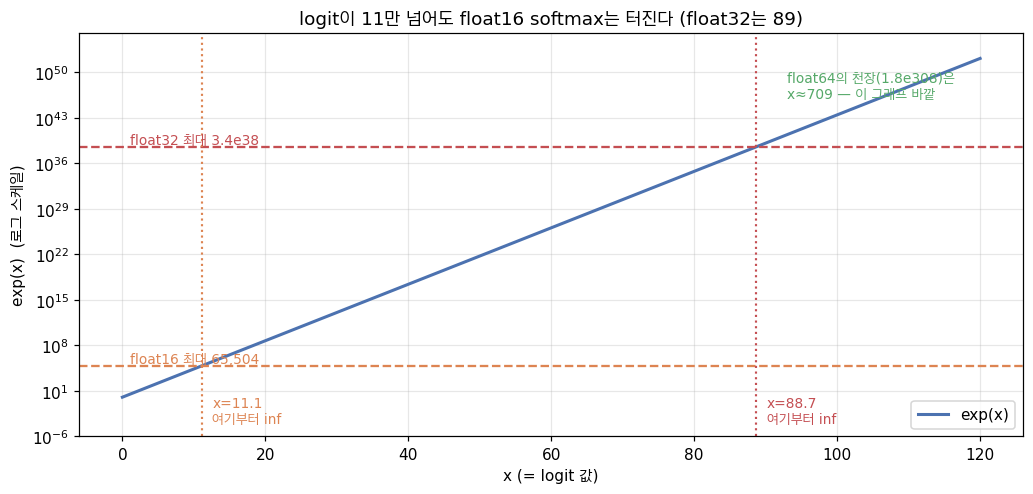

In [23]:
xs = np.linspace(0, 120, 500)
ys = np.exp(xs)

fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.semilogy(xs, ys, lw=2, color="#4c72b0", label="exp(x)")
for limit, label, color in [
    (float(np.finfo(np.float16).max), "float16 최대 65,504", "#dd8452"),
    (float(np.finfo(np.float32).max), "float32 최대 3.4e38", "#c44e52"),
]:
    ax.axhline(limit, ls="--", lw=1.5, color=color)
    ax.text(1, limit * 3, label, color=color, fontsize=9)

for x_cliff, color in [(math.log(65504), "#dd8452"), (88.7, "#c44e52")]:
    ax.axvline(x_cliff, ls=":", lw=1.4, color=color)
    ax.text(x_cliff + 1.5, 1e-4, f"x={x_cliff:.1f}\n여기부터 inf", color=color, fontsize=9)

ax.text(93, 1e46, "float64의 천장(1.8e308)은\nx≈709 — 이 그래프 바깥", fontsize=9, color="#55a868")
ax.set_ylim(1e-6, 1e56)
ax.set_xlabel("x (= logit 값)")
ax.set_ylabel("exp(x)  (로그 스케일)")
ax.set_title("logit이 11만 넘어도 float16 softmax는 터진다 (float32는 89)")
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5️⃣ 🔑 log-sum-exp 트릭 — 이 레슨의 핵심 벽돌

### 🧸 비유 — 키 재기 전에 모두를 같은 바닥에 세우기

반 전체의 키를 재는데 어떤 아이는 10층 옥상에, 어떤 아이는 지하실에 서 있다.
자를 아무리 길게 만들어도 안 된다. **답은 자를 늘리는 게 아니라, 기준 바닥을 옮기는 것.**
가장 높이 서 있는 아이를 기준(0m)으로 잡으면 나머지는 전부 그 아래에 들어온다.

`exp()`도 똑같다. **가장 큰 값을 먼저 빼서 모두를 0 이하로 내리면 절대 넘치지 않는다.**

### 📐 개념 — 유도

```
log(Σ exp(x_i))
= log(Σ exp(x_i - c + c))            (c를 빼고 더한다)
= log(Σ exp(x_i - c)·exp(c))         (exp(a+b) = exp(a)·exp(b))
= log(exp(c) · Σ exp(x_i - c))       (exp(c)를 밖으로)
= c + log(Σ exp(x_i - c))            (log(ab) = log a + log b)
```

**`c = max(x)`** 로 두면:

- 가장 큰 지수가 `exp(0) = 1` → **오버플로 불가능**
- 합에 최소한 1이 있으므로 합 ≥ 1 → `log(≥1) ≥ 0` → **`-inf` 불가능**

$$\log\sum_i e^{x_i} \;=\; \max_i x_i \;+\; \log\sum_i e^{\,x_i - \max_i x_i}$$

> ⚠️ **이건 최적화가 아니라 정확성의 요구조건이다.** 결과값은 수학적으로 완전히 동일하다.

### 🏭 이 트릭이 등장하는 곳

softmax 정규화 · cross-entropy · 시퀀스 모델의 로그확률 합산 · 가우시안 혼합 · 변분추론 · **어텐션**

In [24]:
def logsumexp_naive(values):
    return math.log(sum(math.exp(v) for v in values))

def logsumexp_stable(values):
    c = max(values)
    return c + math.log(sum(math.exp(v - c) for v in values))

def naive_str(vals):
    # naive 구현이 어떻게 실패하는지까지 문자열로 남긴다
    try:
        return f"{logsumexp_naive(vals):.6f}"
    except OverflowError:
        return "OverflowError"      # exp가 넘침
    except ValueError:
        return "log(0) = -inf"      # exp가 전부 0으로 언더플로

print(f"{'입력':<28}{'naive':>18}{'stable':>18}")
print("-" * 64)
for name, vals in [
    ("작은 값 [1,2,3]",        [1.0, 2.0, 3.0]),
    ("큰 값 [500,501,502]",    [500.0, 501.0, 502.0]),
    ("아주 작은 값 [-1000]*3", [-1000.0, -1000.0, -1000.0]),
]:
    print(f"{name:<28}{naive_str(vals):>18}{logsumexp_stable(vals):>18.6f}")

print("\n검증: 모든 값이 같으면 logsumexp([a]*n) = a + log(n)")
print(f"  stable([-1000]*3) = {logsumexp_stable([-1000.0]*3):.6f}")
print(f"  -1000 + log(3)    = {-1000 + math.log(3):.6f}")
print("\nnaive가 [-1000]*3에서 하는 일:", naive_str([-1000.0]*3),
      "<- exp가 모두 0으로 언더플로 -> log(0)")
print("  (NumPy로 하면 예외 대신 -inf가 나온다:",
      float(np.log(np.sum(np.exp(np.array([-1000.0]*3))))), ")")

입력                                       naive            stable
----------------------------------------------------------------
작은 값 [1,2,3]                          3.407606          3.407606
큰 값 [500,501,502]                   502.407606        502.407606
아주 작은 값 [-1000]*3                log(0) = -inf       -998.901388

검증: 모든 값이 같으면 logsumexp([a]*n) = a + log(n)
  stable([-1000]*3) = -998.901388
  -1000 + log(3)    = -998.901388

naive가 [-1000]*3에서 하는 일: log(0) = -inf <- exp가 모두 0으로 언더플로 -> log(0)
  (NumPy로 하면 예외 대신 -inf가 나온다: -inf )


/var/folders/9w/m7__0lhd16xcy6bzy6qwytpc0000gn/T/ipykernel_75001/643021667.py:32: RuntimeWarning: divide by zero encountered in log
  float(np.log(np.sum(np.exp(np.array([-1000.0]*3))))), ")")


### 🖼️ 그림 5 — 값을 통째로 평행이동시키면 naive는 양쪽에서 죽는다

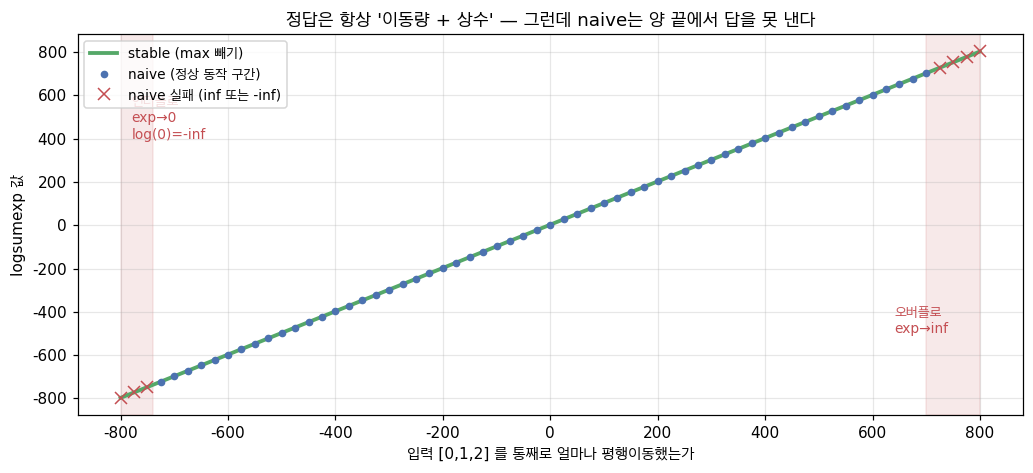

naive가 실패한 구간 비율(float64): 7/65 = 11%
  float64 안전 구간: 대략 |x| < 709
  float32 안전 구간: 대략 |x| < 88.7  <- 학습은 여기서 돈다. 훨씬 좁다


In [25]:
shifts = np.arange(-800, 801, 25)
base = np.array([0.0, 1.0, 2.0])
naive_vals, stable_vals = [], []
for s in shifts:
    v = base + s
    with np.errstate(over="ignore", divide="ignore"):
        naive_vals.append(np.log(np.sum(np.exp(v))))
    stable_vals.append(logsumexp_stable(list(v)))

naive_vals = np.array(naive_vals)
stable_vals = np.array(stable_vals)
bad = ~np.isfinite(naive_vals)

fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.plot(shifts, stable_vals, lw=2.5, label="stable (max 빼기)", color="#55a868")
ax.plot(shifts[~bad], naive_vals[~bad], "o", ms=4, label="naive (정상 동작 구간)", color="#4c72b0")
ax.plot(shifts[bad], np.interp(shifts[bad], shifts, stable_vals), "x", ms=8,
        label="naive 실패 (inf 또는 -inf)", color="#c44e52")
ax.axvspan(-800, -740, alpha=0.12, color="#c44e52")
ax.axvspan(700, 800, alpha=0.12, color="#c44e52")
ax.text(-780, 400, "언더플로\nexp→0\nlog(0)=-inf", fontsize=9, color="#c44e52")
ax.text(640, -500, "오버플로\nexp→inf", fontsize=9, color="#c44e52")
ax.set_xlabel("입력 [0,1,2] 를 통째로 얼마나 평행이동했는가")
ax.set_ylabel("logsumexp 값")
ax.set_title("정답은 항상 '이동량 + 상수' — 그런데 naive는 양 끝에서 답을 못 낸다")
ax.legend(loc="upper left", fontsize=9)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"naive가 실패한 구간 비율(float64): {bad.sum()}/{len(bad)} = {bad.mean()*100:.0f}%")
print(f"  float64 안전 구간: 대략 |x| < 709")
print(f"  float32 안전 구간: 대략 |x| < 88.7  <- 학습은 여기서 돈다. 훨씬 좁다")

## 6️⃣ 🔨 Build It Step 1~4 — 안정 softmax · cross-entropy

### 📐 softmax에 왜 max 빼기가 필요한가

$$\text{softmax}(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}}
= \frac{e^{x_i - c}}{\sum_j e^{x_j - c}} \quad (\text{임의의 } c)$$

분자·분모에 `exp(-c)`를 곱한 것이므로 **값은 완전히 같다.** `c = max(x)` 로 두면 오버플로만 사라진다.

```
logits [100, 101, 102]  (float32 기준)

naive  : exp(100)=inf, exp(101)=inf, exp(102)=inf -> inf/inf = nan
stable : exp(-2)=0.135, exp(-1)=0.368, exp(0)=1.0 -> [0.090, 0.245, 0.665] ✅
```

> ⚠️ 파이썬의 `float`는 사실 **float64**라 100 정도는 버틴다. 하지만 800에서 똑같이 죽고,
> **학습이 실제로 도는 float32/float16에서는 훨씬 일찍 죽는다.** 경계 위치만 다를 뿐 문제는 동일하다.

### 📐 cross-entropy는 한 발 더 나간다

정답이 원-핫이면 `CE = -log(softmax(x)[y])` 다. **softmax를 만든 뒤 log를 취하면 두 번 위험**하다
(softmax가 언더플로해서 0이 되면 `log(0) = -inf`).
대신 **log를 softmax 안으로 밀어 넣는다:**

$$\log \text{softmax}(x)_y = (x_y - c) - \log\sum_j e^{x_j - c}$$

`exp` → `log` 왕복이 사라진다. 이게 PyTorch `F.log_softmax` / `F.cross_entropy` 가 하는 일이다.

In [26]:
def softmax_stable(logits):
    m = max(logits)
    exps = [math.exp(z - m) for z in logits]
    total = sum(exps)
    return [e / total for e in exps]

def log_softmax_stable(logits):
    m = max(logits)
    shifted = [z - m for z in logits]
    lse = math.log(sum(math.exp(s) for s in shifted))
    return [s - lse for s in shifted]

def cross_entropy_naive(true_class, logits):
    probs = softmax_naive(logits)
    return -math.log(probs[true_class])

def cross_entropy_stable(true_class, logits):
    return -log_softmax_stable(logits)[true_class]

safe = [2.0, 1.0, 0.1]
print("[안전한 logit] 두 구현은 같은 답을 준다")
print("  naive :", [f"{p:.6f}" for p in softmax_naive(safe)])
print("  stable:", [f"{p:.6f}" for p in softmax_stable(safe)])
print("  최대 차이:", max(abs(a - b) for a, b in zip(softmax_naive(safe), softmax_stable(safe))))

danger = [100.0, 101.0, 102.0]
print("\n[위험한 logit 100~102]")
print("  naive (float32) :", softmax_naive_f32(danger), "  <- nan. 학습 사망")
print("  stable          :", [f"{p:.6f}" for p in softmax_stable(danger)])
print("  검증            : 합 =", sum(softmax_stable(danger)))

huge = [800.0, 801.0, 802.0]
print("\n[더 위험한 logit 800~802 — float64도 죽는 구간]")
try:
    print("  naive (float64):", softmax_naive(huge))
except OverflowError as e:
    print("  naive (float64): OverflowError -", e)
print("  stable         :", [f"{p:.6f}" for p in softmax_stable(huge)],
      "<- 값은 100~102일 때와 완전히 동일하다")

print("\n[cross-entropy] logits=[2,5,1], 정답=1")
print(f"  naive : {cross_entropy_naive(1, [2.0, 5.0, 1.0]):.6f}")
print(f"  stable: {cross_entropy_stable(1, [2.0, 5.0, 1.0]):.6f}")

print("\n[cross-entropy] logits=[900, 800, 1000], 정답=0  <- 학습 발산 직전 상황")
try:
    print(f"  naive : {cross_entropy_naive(0, [900.0, 800.0, 1000.0]):.6f}")
except OverflowError as e:
    print("  naive : OverflowError -", e)
print(f"  stable: {cross_entropy_stable(0, [900.0, 800.0, 1000.0]):.6f}   <- 손실 100. 크지만 유한한 값!")

[안전한 logit] 두 구현은 같은 답을 준다
  naive : ['0.659001', '0.242433', '0.098566']
  stable: ['0.659001', '0.242433', '0.098566']
  최대 차이: 2.7755575615628914e-17

[위험한 logit 100~102]
  naive (float32) : [nan, nan, nan]   <- nan. 학습 사망
  stable          : ['0.090031', '0.244728', '0.665241']
  검증            : 합 = 0.9999999999999999

[더 위험한 logit 800~802 — float64도 죽는 구간]
  naive (float64): OverflowError - math range error
  stable         : ['0.090031', '0.244728', '0.665241'] <- 값은 100~102일 때와 완전히 동일하다

[cross-entropy] logits=[2,5,1], 정답=1
  naive : 0.065884
  stable: 0.065884

[cross-entropy] logits=[900, 800, 1000], 정답=0  <- 학습 발산 직전 상황
  naive : OverflowError - math range error
  stable: 100.000000   <- 손실 100. 크지만 유한한 값!


In [27]:
# 🏭 실무 대조 — PyTorch가 내부적으로 하는 일과 정확히 같은가?
import torch
import torch.nn.functional as F

logits_t = torch.tensor([900.0, 800.0, 1000.0])
target_t = torch.tensor([0])

print("PyTorch F.log_softmax :", F.log_softmax(logits_t, dim=0).tolist())
print("내 log_softmax_stable :", log_softmax_stable([900.0, 800.0, 1000.0]))
print()
print("PyTorch F.cross_entropy:",
      float(F.cross_entropy(logits_t.unsqueeze(0), target_t)))
print("내 cross_entropy_stable:", cross_entropy_stable(0, [900.0, 800.0, 1000.0]))
print()
print("torch.logsumexp        :", float(torch.logsumexp(torch.tensor([500., 501., 502.]), dim=0)))
print("내 logsumexp_stable    :", logsumexp_stable([500.0, 501.0, 502.0]))
print()
print("❌ 하지 말 것: log(softmax(x)) 를 따로 계산하기")
tiny = torch.tensor([0.0, -300.0, -400.0])
print("  torch.log(torch.softmax(x)) =", torch.log(torch.softmax(tiny, dim=0)).tolist(),
      "<- -inf 발생")
print("  F.log_softmax(x)            =", F.log_softmax(tiny, dim=0).tolist(), "<- 정상")

PyTorch F.log_softmax : [-100.0, -200.0, 0.0]
내 log_softmax_stable : [-100.0, -200.0, 0.0]

PyTorch F.cross_entropy: 100.0
내 cross_entropy_stable: 100.0

torch.logsumexp        : 502.4075927734375
내 logsumexp_stable    : 502.4076059644444

❌ 하지 말 것: log(softmax(x)) 를 따로 계산하기
  torch.log(torch.softmax(x)) = [0.0, -inf, -inf] <- -inf 발생
  F.log_softmax(x)            = [0.0, -300.0, -400.0] <- 정상


## 7️⃣ 🔨 Build It Step 5 — 그래디언트 체킹

### 🧸 비유 — 계산기로 검산하기

역전파로 구한 해석적 그래디언트에는 **버그가 있을 수 있다.**
검산 방법은 초등학교 때와 같다: **아주 조금 움직여 보고 얼마나 변하는지 직접 재 본다.**

### 📐 중심 차분 (centered difference)

$$\frac{df}{dx} \approx \frac{f(x+h) - f(x-h)}{2h}$$

- 전방 차분 `(f(x+h)-f(x))/h` 는 오차가 **O(h)**
- 중심 차분은 오차가 **O(h²)** → 같은 `h`에서 훨씬 정확하다

**`h` 선택이 이 절의 핵심이자, 3절 파괴적 상쇄의 실전 사례다.**

- `h`가 크면 → **근사 오차**(테일러 절단 오차)가 크다
- `h`가 작으면 → `f(x+h)`와 `f(x-h)`가 거의 같아져 **파괴적 상쇄**로 답이 잡음이 된다

→ 두 오차의 합이 최소가 되는 골짜기가 있고, float64에서는 대략 **`h = 1e-5 ~ 1e-7`** 이다.

### 📐 판정 기준

$$\text{rel\_error} = \frac{|g_{\text{해석}} - g_{\text{수치}}|}{\max(|g_{\text{해석}}|, |g_{\text{수치}}|, 10^{-8})}$$

| rel_error | 판정 |
| --- | --- |
| < 1e-7 | 완벽 |
| < 1e-5 | 통과 (아마 맞음) |
| > 1e-3 | 뭔가 잘못됨 |
| > 1 | 완전히 틀림 |

In [28]:
def numerical_gradient(f, x, h=1e-5):
    grad = []
    for i in range(len(x)):
        xp, xm = list(x), list(x)
        xp[i] += h
        xm[i] -= h
        grad.append((f(xp) - f(xm)) / (2 * h))
    return grad

def check_gradient(analytical, numerical, tolerance=1e-5):
    ok = True
    for i, (a, n) in enumerate(zip(analytical, numerical)):
        denom = max(abs(a), abs(n), 1e-8)
        rel = abs(a - n) / denom
        status = "OK" if rel < tolerance else "FAIL"
        ok &= rel < tolerance
        print(f"  param {i}: 해석={a:>12.8f}  수치={n:>12.8f}  rel_error={rel:.2e} [{status}]")
    return ok

# f(x,y) = x² + 3xy + y³
def f(p):
    x, y = p
    return x**2 + 3 * x * y + y**3

def f_grad(p):
    x, y = p
    return [2 * x + 3 * y, 3 * x + 3 * y**2]

point = [2.0, 1.0]
print("f(x,y) = x² + 3xy + y³  at (2, 1)")
check_gradient(f_grad(point), numerical_gradient(f, point))

# 일부러 버그를 심어 본다 (3x -> 2x 오타)
def f_grad_buggy(p):
    x, y = p
    return [2 * x + 3 * y, 2 * x + 3 * y**2]

print("\n버그가 있는 역전파라면? (3x를 2x로 오타)")
check_gradient(f_grad_buggy(point), numerical_gradient(f, point))

f(x,y) = x² + 3xy + y³  at (2, 1)
  param 0: 해석=  7.00000000  수치=  7.00000000  rel_error=1.29e-11 [OK]
  param 1: 해석=  9.00000000  수치=  9.00000000  rel_error=1.15e-11 [OK]

버그가 있는 역전파라면? (3x를 2x로 오타)
  param 0: 해석=  7.00000000  수치=  7.00000000  rel_error=1.29e-11 [OK]
  param 1: 해석=  7.00000000  수치=  9.00000000  rel_error=2.22e-01 [FAIL]


False

### 🖼️ 그림 6 — `h`는 왜 1e-5인가 (근사 오차 vs 상쇄 오차의 골짜기)

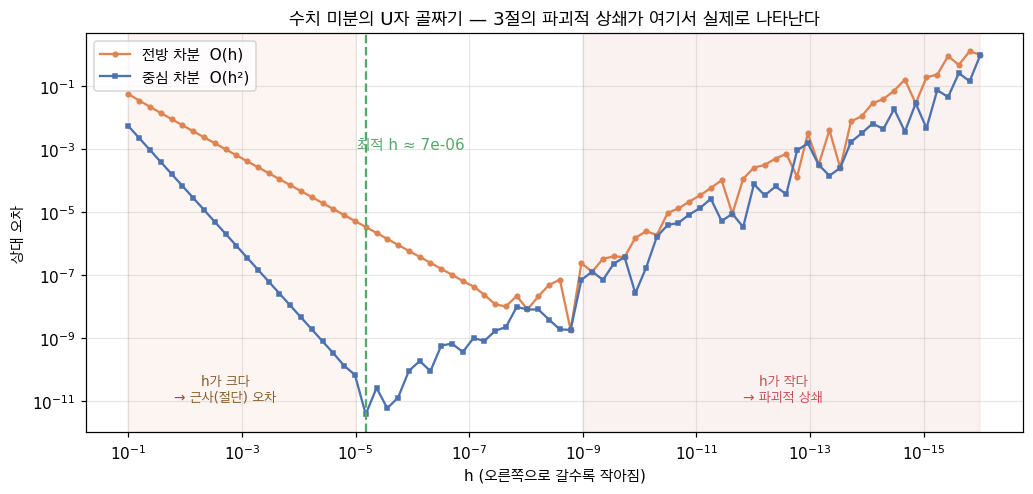

In [29]:
# f(x) = exp(sin(x)) 의 x=1.0 에서의 도함수 = exp(sin(x))·cos(x)
g = lambda x: math.exp(math.sin(x))
g_prime = lambda x: math.exp(math.sin(x)) * math.cos(x)
x0 = 1.0
true_grad = g_prime(x0)

hs = np.logspace(-1, -16, 80)
err_fwd, err_ctr = [], []
for h in hs:
    fwd = (g(x0 + h) - g(x0)) / h
    ctr = (g(x0 + h) - g(x0 - h)) / (2 * h)
    err_fwd.append(abs(fwd - true_grad) / abs(true_grad))
    err_ctr.append(abs(ctr - true_grad) / abs(true_grad))

best_h = hs[int(np.argmin(err_ctr))]

fig, ax = plt.subplots(figsize=(9.5, 4.6))
ax.loglog(hs, np.maximum(err_fwd, 1e-18), "o-", ms=3, label="전방 차분  O(h)", color="#dd8452")
ax.loglog(hs, np.maximum(err_ctr, 1e-18), "s-", ms=3, label="중심 차분  O(h²)", color="#4c72b0")
ax.axvline(best_h, color="#55a868", ls="--", lw=1.5)
ax.text(best_h * 1.4, 1e-3, f"최적 h ≈ {best_h:.0e}", color="#55a868", fontsize=10)
ax.axvspan(1e-1, 1e-5, alpha=0.08, color="#dd8452")
ax.axvspan(1e-9, 1e-16, alpha=0.08, color="#c44e52")
ax.text(2e-3, 1e-11, "h가 크다\n→ 근사(절단) 오차", fontsize=9, color="#8a5a2b", ha="center")
ax.text(3e-13, 1e-11, "h가 작다\n→ 파괴적 상쇄", fontsize=9, color="#c44e52", ha="center")
ax.invert_xaxis()
ax.set_xlabel("h (오른쪽으로 갈수록 작아짐)")
ax.set_ylabel("상대 오차")
ax.set_title("수치 미분의 U자 골짜기 — 3절의 파괴적 상쇄가 여기서 실제로 나타난다")
ax.legend()
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

In [30]:
# 🏭 실무 — 직접 만든 선형층의 역전파를 검증한다 (연습문제 4번의 답이기도 하다)
rng = np.random.default_rng(0)
W = rng.normal(size=(3, 2))
b = rng.normal(size=3)
x = rng.normal(size=2)

def loss_from_params(flat):
    # flat = [W(3x2) 6개, b 3개] -> 스칼라 손실 (0.5*||Wx+b||^2)
    Wl = np.array(flat[:6]).reshape(3, 2)
    bl = np.array(flat[6:])
    y = Wl @ x + bl
    return 0.5 * float(y @ y)

def analytic_grad(flat):
    Wl = np.array(flat[:6]).reshape(3, 2)
    bl = np.array(flat[6:])
    y = Wl @ x + bl                 # dL/dy = y
    dW = np.outer(y, x)             # dL/dW = dL/dy · xᵀ
    db = y                          # dL/db = dL/dy
    return list(dW.ravel()) + list(db)

flat = list(W.ravel()) + list(b)
print("선형층 y = Wx + b,  L = 0.5·||y||²  의 그래디언트 체크")
passed = check_gradient(analytic_grad(flat), numerical_gradient(loss_from_params, flat))
print(f"\n전체 판정: {'✅ PASS' if passed else '❌ FAIL'}")

# PyTorch autograd 와 대조
Wt = torch.tensor(W, requires_grad=True)
bt = torch.tensor(b, requires_grad=True)
xt = torch.tensor(x)
L = 0.5 * ((Wt @ xt + bt) ** 2).sum()
L.backward()
print("\nPyTorch autograd dW:\n", Wt.grad.numpy())
print("내 해석적 dW:\n", np.array(analytic_grad(flat)[:6]).reshape(3, 2))

선형층 y = Wx + b,  L = 0.5·||y||²  의 그래디언트 체크
  param 0: 해석= -1.55297067  수치= -1.55297067  rel_error=4.11e-12 [OK]
  param 1: 해석= -0.76490480  수치= -0.76490480  rel_error=6.11e-12 [OK]
  param 2: 해석= -0.09021800  수치= -0.09021800  rel_error=3.43e-12 [OK]
  param 3: 해석= -0.04443624  수치= -0.04443624  rel_error=8.71e-11 [OK]
  param 4: 해석=  0.31795065  수치=  0.31795065  rel_error=8.89e-12 [OK]
  param 5: 해석=  0.15660436  수치=  0.15660436  rel_error=1.18e-11 [OK]
  param 6: 해석=  1.22723591  수치=  1.22723591  rel_error=9.52e-12 [OK]
  param 7: 해석=  0.07129483  수치=  0.07129483  rel_error=7.33e-11 [OK]
  param 8: 해석= -0.25126067  수치= -0.25126067  rel_error=8.65e-12 [OK]

전체 판정: ✅ PASS

PyTorch autograd dW:
 [[-1.552971 -0.764905]
 [-0.090218 -0.044436]
 [ 0.317951  0.156604]]
내 해석적 dW:
 [[-1.552971 -0.764905]
 [-0.090218 -0.044436]
 [ 0.317951  0.156604]]


## 8️⃣ 혼합 정밀도 · float16 vs bfloat16 · loss scaling

### 🧸 비유 — 정밀 저울과 대형 저울

- **float16 = 약국 저울**: 눈금은 촘촘한데(정밀), 65kg을 넘으면 아예 못 잰다(범위 좁음).
- **bfloat16 = 화물 저울**: 눈금은 성긴데(부정밀), 수 톤까지 잰다(범위 넓음).

딥러닝 학습에서는 **활성값이 튀는 순간**과 **그래디언트가 극히 작아지는 순간**이 둘 다 온다.
즉 **범위가 정밀도보다 중요**하다 → 그래서 bfloat16이 이긴다.

### 📐 혼합 정밀도 학습의 흐름

```
1. float32 마스터 가중치를 따로 보관
2. 순전파는 float16 (Tensor Core, 2~8배 빠름)
3. 손실은 float32로 계산 (오버플로 방지)
4. 역전파는 float16
5. 그래디언트를 float32로 되돌림
6. float32 마스터 가중치를 갱신
```

### 📐 순수 float16의 문제와 loss scaling

그래디언트는 흔히 `1e-8` 이하로 작다. float16은 약 `6e-8` 아래를 전부 0으로 만든다.
→ **모든 업데이트가 0이 되어 모델이 학습을 멈춘다.**

```
1. 손실에 큰 상수를 곱한다 (예: 1024)
2. 역전파가 (loss × 1024)의 그래디언트를 계산
3. 모든 그래디언트가 1024배 → float16 언더플로 경계 위로 올라옴
4. 가중치 갱신 전에 1024로 나눈다
5. 순 효과: 업데이트는 같고, 언더플로만 사라짐
```

**동적 loss scaling**: 65536에서 시작 → `inf`가 나오면 절반으로, N스텝 무사하면 두 배로.

### 📐 bfloat16이 학습에서 이기는 이유

```
float16 : [1 부호] [5 지수]  [10 가수]   범위 ±65,504
bfloat16: [1 부호] [8 지수]  [7 가수]    범위 ±3.4e38  (float32와 동일)
```

- 학습 스파이크 때 활성값·logit이 65,504를 넘긴다 → float16은 `inf`, bfloat16은 멀쩡
- float16은 loss scaling이 **필수**, bfloat16은 보통 **불필요**
- bfloat16은 float32의 **하위 16비트를 잘라내기만** 하면 되므로 변환이 단순하다

→ 그래서 TPU와 최신 NVIDIA GPU(A100/H100)는 bfloat16을 네이티브 지원한다.

In [31]:
def to_float16(x):
    # float16 라운드트립. struct의 'e'도 IEEE 754 binary16이지만 범위를 넘으면 예외를 던지므로,
    # 하드웨어와 같게 inf로 포화시키려면 numpy 캐스팅을 쓴다.
    with np.errstate(over="ignore"):
        return float(np.float16(x))

def to_bfloat16(x):
    # float32의 하위 16비트를 잘라내면 그게 bfloat16이다 (절삭 방식)
    as_int = int.from_bytes(struct.pack("f", x), "little")
    truncated = as_int & 0xFFFF0000
    return struct.unpack("f", truncated.to_bytes(4, "little"))[0]

print(f"{'원본 값':>14}{'float16':>18}{'bfloat16':>18}   비고")
print("-" * 74)
cases = [(3.14159265, "정밀도 비교 — fp16 승"),
         (1e-8, "작은 그래디언트 — fp16 언더플로"),
         (70000.0, "큰 활성값 — fp16 오버플로"),
         (1e20, "매우 큰 값"),
         (0.1, "일상적인 값")]
for v, note in cases:
    f16 = to_float16(v)
    bf16 = to_bfloat16(v)
    print(f"{v:>14.8g}{f16:>18.8g}{bf16:>18.8g}   {note}")

# torch로 교차 검증
print("\n[torch 교차 검증]")
for v in [3.14159265, 1e-8, 70000.0]:
    t = torch.tensor(v, dtype=torch.float32)
    print(f"  {v:>12g} -> fp16 {float(t.to(torch.float16)):>14g}"
          f"  bf16 {float(t.to(torch.bfloat16)):>14g}")

          원본 값           float16          bfloat16   비고
--------------------------------------------------------------------------
     3.1415927          3.140625          3.140625   정밀도 비교 — fp16 승
         1e-08                 0       9.95351e-09   작은 그래디언트 — fp16 언더플로
         70000               inf             69632   큰 활성값 — fp16 오버플로
         1e+20               inf      9.972771e+19   매우 큰 값
           0.1       0.099975586       0.099609375   일상적인 값

[torch 교차 검증]
       3.14159 -> fp16        3.14062  bf16        3.14062
         1e-08 -> fp16              0  bf16    1.00117e-08
         70000 -> fp16            inf  bf16          70144


### 🖼️ 그림 7 — 그래디언트 언더플로와 loss scaling의 효과

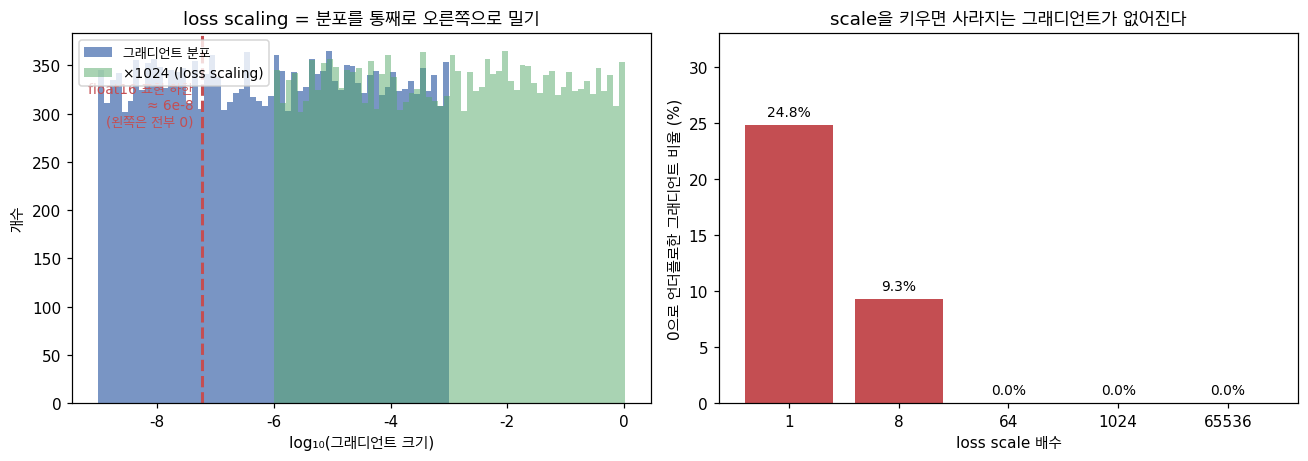

  loss scale ×1     : 언더플로 비율 24.79%
  loss scale ×8     : 언더플로 비율  9.27%
  loss scale ×64    : 언더플로 비율  0.00%
  loss scale ×1024  : 언더플로 비율  0.00%
  loss scale ×65536 : 언더플로 비율  0.00%


In [32]:
rng = np.random.default_rng(42)
# 실제 학습의 그래디언트 크기 분포를 흉내 — 로그 스케일로 넓게 퍼진다
grads = 10 ** rng.uniform(-9, -3, size=20000)

def frac_zero(g, scale=1.0):
    conv = np.array([to_float16(v * scale) for v in g])
    return float(np.mean(conv == 0.0))

scales = [1, 8, 64, 1024, 65536]
fracs = [frac_zero(grads, s) for s in scales]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.3))

fp16_tiny = float(np.finfo(np.float16).tiny)          # 최소 정규값 6.1e-5
fp16_smallest = 2.0 ** -24                            # 최소 비정규값 ≈ 5.96e-8
ax1.hist(np.log10(grads), bins=60, color="#4c72b0", alpha=0.75, label="그래디언트 분포")
ax1.axvline(np.log10(fp16_smallest), color="#c44e52", ls="--", lw=2)
ax1.text(np.log10(fp16_smallest) - 0.15, ax1.get_ylim()[1] * 0.75,
         "float16 표현 하한\n≈ 6e-8\n(왼쪽은 전부 0)", color="#c44e52", fontsize=9, ha="right")
shifted = np.log10(grads * 1024)
ax1.hist(shifted, bins=60, color="#55a868", alpha=0.5, label="×1024 (loss scaling)")
ax1.set_xlabel("log₁₀(그래디언트 크기)")
ax1.set_ylabel("개수")
ax1.set_title("loss scaling = 분포를 통째로 오른쪽으로 밀기")
ax1.legend(fontsize=9)

bars = ax2.bar([str(s) for s in scales], [f * 100 for f in fracs],
               color=["#c44e52" if f > 0.05 else "#55a868" for f in fracs])
for b, f in zip(bars, fracs):
    ax2.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.8,
             f"{f*100:.1f}%", ha="center", fontsize=9)
ax2.set_xlabel("loss scale 배수")
ax2.set_ylabel("0으로 언더플로한 그래디언트 비율 (%)")
ax2.set_title("scale을 키우면 사라지는 그래디언트가 없어진다")
ax2.set_ylim(0, max(fracs) * 100 * 1.25 + 2)
plt.tight_layout()
plt.show()

for s, f in zip(scales, fracs):
    print(f"  loss scale ×{s:<6}: 언더플로 비율 {f*100:5.2f}%")

In [33]:
# 🏭 실무 — 동적 loss scaling을 30줄로 구현해 본다 (torch.cuda.amp.GradScaler의 핵심)
class DynamicLossScaler:
    def __init__(self, init_scale=65536.0, growth_interval=200, growth_factor=2.0,
                 backoff_factor=0.5):
        self.scale = init_scale
        self.growth_interval = growth_interval
        self.growth_factor = growth_factor
        self.backoff_factor = backoff_factor
        self._good_steps = 0

    def step(self, grads_fp16):
        # 반환: (업데이트를 적용해도 되는가, 되돌린 그래디언트)
        if any(not math.isfinite(g) for g in grads_fp16):
            self.scale *= self.backoff_factor      # inf/nan -> 스텝 건너뛰고 scale 축소
            self._good_steps = 0
            return False, None
        self._good_steps += 1
        if self._good_steps % self.growth_interval == 0:
            self.scale *= self.growth_factor       # 오래 무사하면 scale 확대
        return True, [g / self.scale for g in grads_fp16]

scaler = DynamicLossScaler(init_scale=65536.0, growth_interval=3)
true_grads = [1e-7, 5e-8, 1e-3]
print(f"{'step':>5}{'scale':>12}{'상황':>22}{'적용':>8}")
print("-" * 50)
for step in range(8):
    spike = (step == 2)                            # 3번째 스텝에서 그래디언트 폭발
    scaled = [g * scaler.scale * (1e6 if spike else 1) for g in true_grads]
    scaled = [v if math.isfinite(to_float16(v)) else float("inf") for v in scaled]
    ok, restored = scaler.step(scaled)
    note = "그래디언트 폭발!" if spike else "정상"
    print(f"{step:>5}{scaler.scale:>12.0f}{note:>22}{'O' if ok else 'X (스킵)':>8}")

 step       scale                    상황      적용
--------------------------------------------------
    0       65536                    정상       O
    1       65536                    정상       O
    2       32768             그래디언트 폭발!  X (스킵)
    3       32768                    정상       O
    4       32768                    정상       O
    5       65536                    정상       O
    6       65536                    정상       O
    7       65536                    정상       O


## 9️⃣ 그래디언트 클리핑 (value vs norm)

### 🧸 비유 — 운전대를 확 꺾지 않기

그래디언트는 "어느 방향으로 얼마나 갈까"다. 이상치 배치 하나가 **핸들을 90도 꺾어 버리면**
몇 주치 학습이 한 스텝에 날아간다. 클리핑은 **"방향은 그대로, 세기만 제한"** 하는 안전장치다.

### 📐 두 가지 방식

**Clip by value** — 원소별로 잘라낸다.

```
grad = clamp(grad, -max_val, max_val)
```
단순하지만 **벡터의 방향이 바뀔 수 있다.**

**Clip by norm** — 벡터 전체를 비율로 줄인다.

```
if ||grad|| > max_norm:
    grad = grad × (max_norm / ||grad||)
```
**방향이 보존된다.** `torch.nn.utils.clip_grad_norm_()` 이 이것이고, 표준 선택지다.

| 모델 | 관행적 `max_norm` |
| --- | --- |
| 트랜스포머 | 1.0 |
| 강화학습 | 0.5 |
| 단순한 신경망 | 5.0 |

> 클리핑은 꼼수가 아니라 **안전 장치**다. 없으면 이상치 배치 하나가 몇 주치 학습을 망친다.

In [34]:
def clip_by_norm(gradients, max_norm):
    total_norm = math.sqrt(sum(g ** 2 for g in gradients))
    if total_norm > max_norm:
        scale = max_norm / total_norm
        return [g * scale for g in gradients]
    return list(gradients)

def clip_by_value(gradients, max_val):
    return [max(-max_val, min(max_val, g)) for g in gradients]

grads = [10.0, 20.0, 30.0]
by_norm = clip_by_norm(grads, max_norm=5.0)
by_value = clip_by_value(grads, max_val=5.0)

norm = lambda v: math.sqrt(sum(x ** 2 for x in v))
print(f"원본      : {grads}   norm={norm(grads):.3f}")
print(f"norm 클립 : {[round(g,4) for g in by_norm]}   norm={norm(by_norm):.3f}")
print(f"value 클립: {by_value}   norm={norm(by_value):.3f}")
print()
print("방향(단위벡터) 비교 — norm 클리핑만 원본과 같다")
unit = lambda v: [round(x / norm(v), 4) for x in v]
print(f"  원본      : {unit(grads)}")
print(f"  norm 클립 : {unit(by_norm)}   <- 동일 ✅")
print(f"  value 클립: {unit(by_value)}   <- 방향이 바뀜 ❌")

# torch와 대조
p = torch.nn.Parameter(torch.zeros(3))
p.grad = torch.tensor([10.0, 20.0, 30.0])
torch.nn.utils.clip_grad_norm_([p], max_norm=5.0)
print("\ntorch.nn.utils.clip_grad_norm_ 결과:", p.grad.tolist())

원본      : [10.0, 20.0, 30.0]   norm=37.417
norm 클립 : [1.3363, 2.6726, 4.0089]   norm=5.000
value 클립: [5.0, 5.0, 5.0]   norm=8.660

방향(단위벡터) 비교 — norm 클리핑만 원본과 같다
  원본      : [0.2673, 0.5345, 0.8018]
  norm 클립 : [0.2673, 0.5345, 0.8018]   <- 동일 ✅
  value 클립: [0.5774, 0.5774, 0.5774]   <- 방향이 바뀜 ❌

torch.nn.utils.clip_grad_norm_ 결과: [1.3363062143325806, 2.672612428665161, 4.008918762207031]


### 🖼️ 그림 8 — 방향이 보존되는가 (2D로 보기)

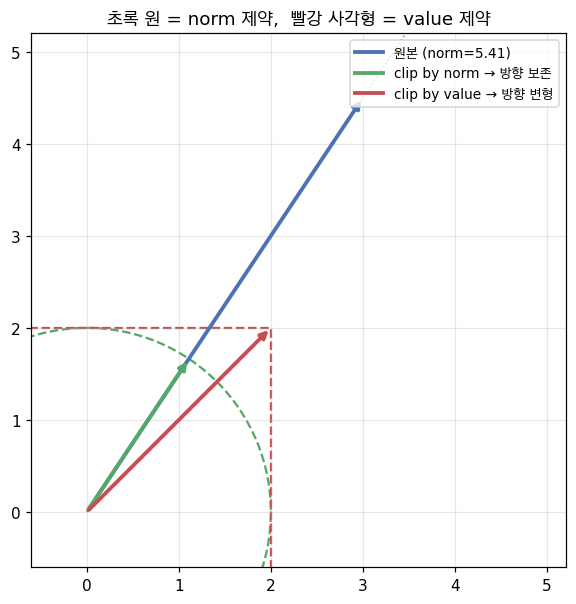

value 클리핑 후 원본과의 코사인 유사도: 0.9806  <- 1.0이 아니면 방향이 틀어진 것


In [35]:
g = np.array([3.0, 4.5])          # norm = 5.41
max_norm, max_val = 2.0, 2.0
g_norm = g * (max_norm / np.linalg.norm(g))
g_value = np.clip(g, -max_val, max_val)

fig, ax = plt.subplots(figsize=(5.6, 5.6))
circle = plt.Circle((0, 0), max_norm, fill=False, ls="--", color="#55a868", lw=1.5)
square = plt.Rectangle((-max_val, -max_val), 2 * max_val, 2 * max_val,
                       fill=False, ls="--", color="#c44e52", lw=1.5)
ax.add_patch(circle)
ax.add_patch(square)

for vec, color, label in [(g, "#4c72b0", f"원본 (norm={np.linalg.norm(g):.2f})"),
                          (g_norm, "#55a868", "clip by norm → 방향 보존"),
                          (g_value, "#c44e52", "clip by value → 방향 변형")]:
    ax.annotate("", xy=vec, xytext=(0, 0),
                arrowprops=dict(arrowstyle="-|>", lw=2.5, color=color))
    ax.plot([], [], color=color, lw=2.5, label=label)

ax.plot([0, g[0] * 1.15], [0, g[1] * 1.15], ls=":", color="gray", lw=1)
ax.set_xlim(-0.6, 5.2)
ax.set_ylim(-0.6, 5.2)
ax.set_aspect("equal")
ax.grid(alpha=0.3)
ax.legend(fontsize=9, loc="upper right")
ax.set_title("초록 원 = norm 제약,  빨강 사각형 = value 제약")
plt.tight_layout()
plt.show()

cos = float(g_value @ g / (np.linalg.norm(g_value) * np.linalg.norm(g)))
print(f"value 클리핑 후 원본과의 코사인 유사도: {cos:.4f}  <- 1.0이 아니면 방향이 틀어진 것")

## 🔟 정규화 층은 사실 '수치 안정 장치'다

배치 정규화 · 레이어 정규화 · RMS 정규화는 보통 **"학습을 잘 되게 하는 정규화"** 로 소개된다.
하지만 이들의 또 다른 정체는 **수치 안정 장치**다.

정규화가 없으면 활성값은 층을 지나며 지수적으로 커지거나 작아진다.

```
Layer  1: [0, 1]
Layer  5: [0, 100]
Layer 10: [0, 10,000]
Layer 50: [0, inf]        ← 순전파가 터진다
```

$$\text{LayerNorm}(x) = \frac{x - \mu(x)}{\sigma(x) + \epsilon}\,\gamma + \beta$$

- `epsilon`(보통 1e-5)은 **모든 활성값이 같을 때의 0으로 나누기**를 막는다.
- 학습 파라미터 `γ`, `β` 덕분에 네트워크는 필요한 스케일을 다시 복원할 수 있다.

→ 매 층마다 값을 **수치적으로 안전한 구간**으로 되돌리므로,
순전파 오버플로와 역전파 그래디언트 폭발을 **동시에** 막는다.

In [36]:
def layer_norm(x, eps=1e-5):
    mu = x.mean()
    sigma = x.std()
    return (x - mu) / (sigma + eps)

rng = np.random.default_rng(7)
n_layers, dim = 60, 128
x0 = rng.normal(size=dim).astype(np.float32)

def run_stack(use_ln, gain):
    x = x0.copy()
    stds = []
    for _ in range(n_layers):
        W = rng.normal(scale=gain / math.sqrt(dim), size=(dim, dim)).astype(np.float32)
        x = x @ W                                   # 선형 스택으로 폭발/소멸을 그대로 관찰
        if use_ln:
            x = layer_norm(x)
        stds.append(float(np.std(x.astype(np.float64))))
    return np.array(stds)

rng = np.random.default_rng(7); explode = run_stack(False, gain=4.0)
rng = np.random.default_rng(7); vanish = run_stack(False, gain=0.25)
rng = np.random.default_rng(7); with_ln = run_stack(True, gain=4.0)

print(f"{'층':>5}{'정규화X(gain 4.0)':>22}{'정규화X(gain 0.25)':>22}{'LayerNorm(gain 4.0)':>24}")
print("-" * 78)
for i in [0, 9, 19, 39, 59]:
    print(f"{i+1:>5}{explode[i]:>24.4e}{vanish[i]:>24.4e}{with_ln[i]:>24.4e}")
print(f"\nfloat32 최대값 {np.finfo(np.float32).max:.3e} 대비 60층 활성값: {explode[-1]:.3e}")

    층        정규화X(gain 4.0)       정규화X(gain 0.25)     LayerNorm(gain 4.0)
------------------------------------------------------------------------------
    1              3.6776e+00              2.2985e-01              1.0000e+00
   10              1.5458e+06              1.4059e-06              1.0000e+00
   20              1.8420e+12              1.5237e-12              1.0000e+00
   40              3.4640e+24              2.3701e-24              1.0000e+00
   60              4.1316e+36              2.3384e-36              1.0000e+00

float32 최대값 3.403e+38 대비 60층 활성값: 4.132e+36


### 🖼️ 그림 9 — 60개 층을 지난 활성값의 표준편차

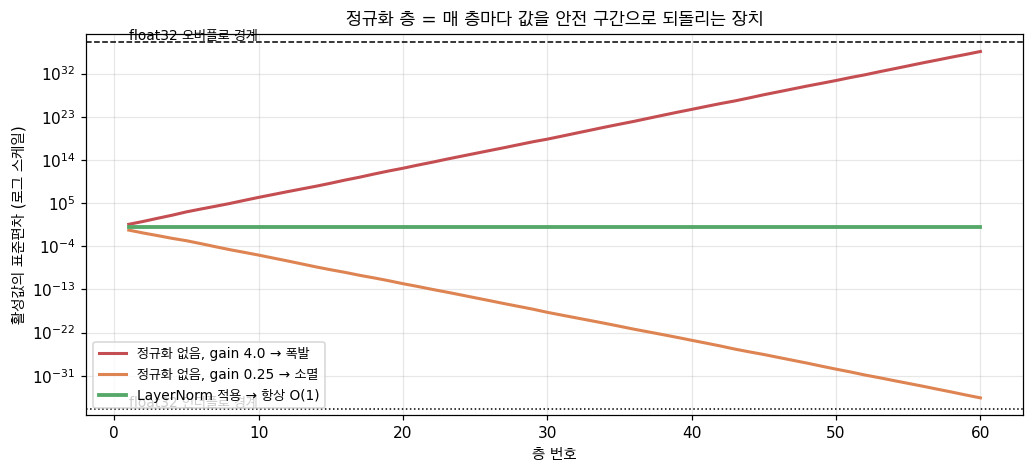

In [37]:
fig, ax = plt.subplots(figsize=(9.5, 4.4))
layers = np.arange(1, n_layers + 1)
ax.semilogy(layers, explode, lw=2, color="#c44e52", label="정규화 없음, gain 4.0 → 폭발")
ax.semilogy(layers, vanish, lw=2, color="#dd8452", label="정규화 없음, gain 0.25 → 소멸")
ax.semilogy(layers, with_ln, lw=2.5, color="#55a868", label="LayerNorm 적용 → 항상 O(1)")
ax.axhline(np.finfo(np.float32).max, color="black", ls="--", lw=1)
ax.text(1, np.finfo(np.float32).max * 3, "float32 오버플로 경계", fontsize=9)
ax.axhline(np.finfo(np.float32).tiny, color="black", ls=":", lw=1)
ax.text(1, np.finfo(np.float32).tiny * 3, "float32 언더플로 경계", fontsize=9)
ax.set_xlabel("층 번호")
ax.set_ylabel("활성값의 표준편차 (로그 스케일)")
ax.set_title("정규화 층 = 매 층마다 값을 안전 구간으로 되돌리는 장치")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.show()

## 1️⃣1️⃣ 🏭 Use It — 흔한 수치 버그 처방전

| 증상 | 원인 | 처방 |
| --- | --- | --- |
| 몇 epoch 뒤 loss가 `NaN` | logit이 커져 softmax 오버플로, 또는 학습률이 너무 높아 가중치 발산 | 안정 softmax(max 빼기), 학습률 낮추기, **그래디언트 클리핑** |
| loss가 `log(클래스수)`에 멈춤 | 출력이 거의 균등분포 = 학습이 아예 안 됨 | 라벨 확인, 손실 함수 검증, dead ReLU 확인 |
| 검증 정확도가 1~3% 낮음 | loss scaling 없는 혼합 정밀도 → 그래디언트 언더플로가 조용히 업데이트를 0으로 | 동적 loss scaling 켜기, 또는 **bfloat16으로 전환** |
| 일부 층의 그래디언트 norm이 `0.0` | dead ReLU(입력이 전부 음수) 또는 float16 언더플로 | LeakyReLU/GELU, 그래디언트 스케일링, 초기화 점검 |
| GPU를 바꾸니 결과가 달라짐 | 부동소수점 덧셈은 **결합법칙이 성립하지 않음** — 병렬 리덕션 순서가 하드웨어마다 다름 | 1e-6 수준 차이는 수용, 또는 `torch.use_deterministic_algorithms(True)` (속도 손해) |
| 손실 계산에서 `exp()`가 `inf` | 원시 logit을 max 빼기 없이 `exp()`에 넣음 | `F.log_softmax()` / `F.cross_entropy()` 사용 |
| float32 → float16 전환 후 발산 | float16은 6e-8 미만 그래디언트, 65,504 초과 활성값을 표현 못 함 | AMP + loss scaling, 또는 **bfloat16** |

### 🛡️ 예방 수칙 6가지

1. `exp()` 입력을 클램프: `exp(clamp(x, -80, 80))`
2. 분모에 엡실론: `x / (y + 1e-8)`
3. `log()` 안에 엡실론: `log(x + 1e-8)`
4. 안정 구현을 쓴다 (log-sum-exp, 안정 softmax)
5. 그래디언트 클리핑으로 가중치 폭발을 막는다
6. 디버깅 중에는 **매 순전파 후** `nan`/`inf` 검사

In [38]:
# 디버깅용 텐서 검사기 — 학습 루프에 훅으로 걸어두면 죽는 지점을 정확히 잡는다
def check_tensor(name, values):
    arr = np.asarray(values, dtype=np.float64)
    has_nan, has_inf = bool(np.isnan(arr).any()), bool(np.isinf(arr).any())
    if has_nan or has_inf:
        print(f"  ⚠️  {name:<12}: nan={has_nan} inf={has_inf}  "
              f"(nan {int(np.isnan(arr).sum())}개, inf {int(np.isinf(arr).sum())}개)")
        return False
    print(f"  ✅ {name:<12}: min={arr.min():>10.3e} max={arr.max():>10.3e} "
          f"mean={arr.mean():>10.3e}")
    return True

print("[텐서 검사]")
check_tensor("good", [1.0, 2.0, 3.0])
check_tensor("bad", [1.0, float("nan"), 3.0])
check_tensor("ugly", [1.0, float("inf"), 3.0])

print("\n[PyTorch 학습 루프에 거는 방식]")
recipe = [
    "# 1) 순전파 중 nan/inf가 생기는 지점을 자동으로 잡아준다 (느리지만 디버깅에 최고)",
    "torch.autograd.set_detect_anomaly(True)",
    "",
    "# 2) 모듈마다 훅을 걸어 어느 층에서 터지는지 특정",
    "for name, module in model.named_modules():",
    "    module.register_forward_hook(",
    "        lambda m, inp, out, n=name: print(n, 'NaN!') if torch.isnan(out).any() else None)",
    "",
    "# 3) 매 스텝 그래디언트 norm을 기록해 두면 폭발 직전을 눈으로 본다",
    "total_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)",
]
print("\n".join(recipe))

[텐서 검사]
  ✅ good        : min= 1.000e+00 max= 3.000e+00 mean= 2.000e+00
  ⚠️  bad         : nan=True inf=False  (nan 1개, inf 0개)
  ⚠️  ugly        : nan=False inf=True  (nan 0개, inf 1개)

[PyTorch 학습 루프에 거는 방식]
# 1) 순전파 중 nan/inf가 생기는 지점을 자동으로 잡아준다 (느리지만 디버깅에 최고)
torch.autograd.set_detect_anomaly(True)

# 2) 모듈마다 훅을 걸어 어느 층에서 터지는지 특정
for name, module in model.named_modules():
    module.register_forward_hook(
        lambda m, inp, out, n=name: print(n, 'NaN!') if torch.isnan(out).any() else None)

# 3) 매 스텝 그래디언트 norm을 기록해 두면 폭발 직전을 눈으로 본다
total_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)


In [39]:
# 🏭 결합법칙이 안 되는 부동소수점 — 같은 수를 더해도 순서가 다르면 결과가 다르다
rng = np.random.default_rng(1)
vals = rng.normal(size=100_000).astype(np.float32) * 1e3

seq = np.float32(0.0)
for v in vals:                  # 순차 합산
    seq += v
pairwise = np.sum(vals)         # NumPy의 pairwise 합산
f64 = np.sum(vals.astype(np.float64))

print(f"순차 합산(float32)   : {float(seq):.6f}")
print(f"NumPy 합산(float32)  : {float(pairwise):.6f}   <- pairwise 알고리즘")
print(f"float64 기준값       : {f64:.6f}")
print(f"\n순차 합산 오차   : {abs(float(seq) - f64):.6e}")
print(f"NumPy 합산 오차  : {abs(float(pairwise) - f64):.6e}")
print("\n=> GPU마다 리덕션 순서가 달라 결과가 미세하게 달라지는 이유가 정확히 이것이다.")
print(f"   (a+b)+c == a+(b+c) ?  {(np.float32(1e10) + np.float32(-1e10)) + np.float32(1.0) == np.float32(1e10) + (np.float32(-1e10) + np.float32(1.0))}")

순차 합산(float32)   : -459056.062500
NumPy 합산(float32)  : -459057.281250   <- pairwise 알고리즘
float64 기준값       : -459057.227091

순차 합산 오차   : 1.164591e+00
NumPy 합산 오차  : 5.415873e-02

=> GPU마다 리덕션 순서가 달라 결과가 미세하게 달라지는 이유가 정확히 이것이다.
   (a+b)+c == a+(b+c) ?  False


## 1️⃣2️⃣ 📝 연습문제 (풀이 포함)

원문 Exercises 5개를 그대로 풀어 본다.

1. **파괴적 상쇄** — `[1000000, 1000001, 1000002]`의 분산을 `E[x²]−E[x]²`(float32)와 Welford로 계산해 참값 0.6667과 비교.
2. **정밀도 사냥** — `1.0 + x == 1.0`이 되는 가장 작은 양수 float32 `x`(머신 엡실론)를 찾고 `np.finfo(np.float32).eps`와 일치하는지 확인.
3. **logsumexp 엣지 케이스** — (a) 모든 값이 같을 때, (b) 하나만 훨씬 클 때, (c) 전부 −1000일 때 naive와 stable을 비교.
4. **선형층 그래디언트 체킹** — `y = Wx + b`의 역전파를 3×2 가중치에서 검증. *(→ 7절에서 이미 완료)*
5. **loss scaling 실험** — `[1e-9, 1e-3]` 범위 그래디언트를 float16으로 변환해 0이 되는 비율을 측정하고, ×1024 후 다시 측정.

In [40]:
print("=" * 66)
print("연습 1 — 파괴적 상쇄")
print("=" * 66)
data = [1_000_000.0, 1_000_001.0, 1_000_002.0]
true_var = 2 / 3
for label, fn in [("naive  E[x²]-E[x]²", variance_naive), ("Welford", variance_welford)]:
    got = fn(data)
    print(f"  {label:<22} = {got:>14.6f}   절대오차 {abs(got-true_var):.6f}   "
          f"상대오차 {abs(got-true_var)/true_var*100:8.2f}%")
print(f"  {'참값':<22} = {true_var:>14.6f}")
print("  💡 결론: 수학적으로 동치인 식도 부동소수점에서는 동치가 아니다.")

연습 1 — 파괴적 상쇄
  naive  E[x²]-E[x]²     =    5673.666626   절대오차 5672.999959   상대오차 850949.99%
  Welford                =       0.666667   절대오차 0.000000   상대오차     0.00%
  참값                     =       0.666667
  💡 결론: 수학적으로 동치인 식도 부동소수점에서는 동치가 아니다.


In [41]:
print("=" * 66)
print("연습 2 — 머신 엡실론 사냥")
print("=" * 66)
one = np.float32(1.0)
eps = np.float32(1.0)
while np.float32(one + eps / np.float32(2.0)) != one:
    eps = np.float32(eps / np.float32(2.0))
print(f"  이분 탐색으로 찾은 float32 eps : {float(eps):.10e}")
print(f"  np.finfo(np.float32).eps      : {float(np.finfo(np.float32).eps):.10e}")
print(f"  일치? {float(eps) == float(np.finfo(np.float32).eps)}")
print(f"\n  검증: 1.0 + eps   != 1.0 ? {np.float32(one + eps) != one}")
print(f"        1.0 + eps/2 != 1.0 ? {np.float32(one + np.float32(eps/2)) != one}  <- 사라진다")
print(f"\n  참고 — float64 eps: {np.finfo(np.float64).eps:.10e}"
      f"   float16 eps: {float(np.finfo(np.float16).eps):.10e}")
print("  💡 eps는 '1.0 근처의 눈금 간격'이다. 값이 커지면 간격도 비례해 커진다 (그림 2).")

연습 2 — 머신 엡실론 사냥
  이분 탐색으로 찾은 float32 eps : 1.1920928955e-07
  np.finfo(np.float32).eps      : 1.1920928955e-07
  일치? True

  검증: 1.0 + eps   != 1.0 ? True
        1.0 + eps/2 != 1.0 ? False  <- 사라진다

  참고 — float64 eps: 2.2204460493e-16   float16 eps: 9.7656250000e-04
  💡 eps는 '1.0 근처의 눈금 간격'이다. 값이 커지면 간격도 비례해 커진다 (그림 2).


In [42]:
print("=" * 66)
print("연습 3 — logsumexp 엣지 케이스")
print("=" * 66)
cases = [
    ("(a) 전부 동일 [5,5,5,5]",     [5.0] * 4,               5.0 + math.log(4)),
    ("(b) 하나만 큼 [0,0,50]",      [0.0, 0.0, 50.0],        None),
    ("(c) 전부 -1000",              [-1000.0] * 3,           -1000 + math.log(3)),
    ("(d) 전부 +1000",              [1000.0] * 3,            1000 + math.log(3)),
]
print(f"{'케이스':<26}{'naive':>16}{'stable':>16}{'참값':>16}")
print("-" * 74)
for name, vals, expected in cases:
    n_str = naive_str(vals)
    s = logsumexp_stable(vals)
    e_str = f"{expected:.6f}" if expected is not None else "—"
    print(f"{name:<26}{n_str:>16}{s:>16.6f}{e_str:>16}")
print("\n  (b)의 해석: 하나가 압도적으로 크면 logsumexp ≈ max 값이다.")
print(f"     stable([0,0,50]) = {logsumexp_stable([0.,0.,50.]):.6f},  max = 50")
print("  💡 stable은 모든 경우에서 답을 주고, naive는 (c)에서 -inf, (d)에서 오버플로.")

연습 3 — logsumexp 엣지 케이스
케이스                                  naive          stable              참값
--------------------------------------------------------------------------
(a) 전부 동일 [5,5,5,5]               6.386294        6.386294        6.386294
(b) 하나만 큼 [0,0,50]               50.000000       50.000000               —
(c) 전부 -1000                 log(0) = -inf     -998.901388     -998.901388
(d) 전부 +1000                 OverflowError     1001.098612     1001.098612

  (b)의 해석: 하나가 압도적으로 크면 logsumexp ≈ max 값이다.
     stable([0,0,50]) = 50.000000,  max = 50
  💡 stable은 모든 경우에서 답을 주고, naive는 (c)에서 -inf, (d)에서 오버플로.


In [43]:
print("=" * 66)
print("연습 5 — loss scaling 실험")
print("=" * 66)
rng = np.random.default_rng(2024)
g = 10 ** rng.uniform(-9, -3, size=50_000)     # [1e-9, 1e-3] 로그균등

print(f"{'loss scale':>12}{'0이 된 비율':>16}{'상대 오차(중앙값)':>22}")
print("-" * 52)
for scale in [1, 16, 256, 1024, 4096, 65536]:
    conv = np.array([to_float16(v * scale) for v in g]) / scale
    zero_frac = float(np.mean(conv == 0.0))
    alive = conv > 0
    rel = float(np.median(np.abs(conv[alive] - g[alive]) / g[alive])) if alive.any() else float("nan")
    print(f"{scale:>12}{zero_frac*100:>15.2f}%{rel:>22.3e}")

print("\n  ⚠️ scale이 너무 크면 이번엔 큰 그래디언트가 float16 최대값(65504)을 넘어 inf가 된다:")
big = 1e-3 * 65536 * 1e3
print(f"     to_float16(1e-3 × 65536 × 1000) = {to_float16(big)}")
print("  💡 그래서 실무는 '동적' loss scaling을 쓴다 — inf가 나오면 자동으로 절반으로 줄인다.")

연습 5 — loss scaling 실험
  loss scale         0이 된 비율            상대 오차(중앙값)
----------------------------------------------------
           1          24.41%             2.074e-03
          16           4.50%             5.012e-04
         256           0.00%             2.599e-04
        1024           0.00%             2.261e-04
        4096           0.00%             1.991e-04
       65536           0.00%             1.694e-04

  ⚠️ scale이 너무 크면 이번엔 큰 그래디언트가 float16 최대값(65504)을 넘어 inf가 된다:
     to_float16(1e-3 × 65536 × 1000) = inf
  💡 그래서 실무는 '동적' loss scaling을 쓴다 — inf가 나오면 자동으로 절반으로 줄인다.


## 1️⃣3️⃣ 📚 용어 사전 (Key Terms)

| 용어 | 사람들이 말하는 것 | 실제 의미 |
| --- | --- | --- |
| **IEEE 754** | "부동소수점 표준" | 이진 부동소수점 포맷·반올림 규칙·특수값(inf, nan)을 정의한 국제 표준. 모든 현대 CPU/GPU가 구현한다 |
| **머신 엡실론** | "정밀도 한계" | `1.0 + e != 1.0` 을 만족하는 가장 작은 `e`. float32에서 약 1.19e-7 |
| **파괴적 상쇄** | "뺄셈하면 정밀도 손실" | 거의 같은 두 수를 빼면 유효숫자가 상쇄되고 반올림 잡음이 결과를 지배한다 |
| **오버플로** | "숫자가 너무 큼" | 표현 가능한 최대값을 넘어 `inf`가 됨. float32에서 `exp(89)` |
| **언더플로** | "숫자가 너무 작음" | 최소 양수보다 0에 가까워 `0.0`이 됨. float32에서 `exp(-104)` |
| **log-sum-exp 트릭** | "max를 먼저 빼라" | `exp(max(x))`를 밖으로 인수분해해 `log(Σexp(x))`를 계산. softmax·CE·로그확률 연산의 기반 |
| **안정 softmax** | "터지지 않는 softmax" | 지수 계산 전에 `max(logits)`를 뺀다. 결과는 수치적으로 동일하고 오버플로는 불가능 |
| **그래디언트 체킹** | "역전파 검산" | 해석적 그래디언트를 유한 차분 수치 그래디언트와 비교해 구현 버그를 잡는 것 |
| **혼합 정밀도** | "순전파 fp16, 역전파 fp32" | 속도가 중요한 연산은 낮은 정밀도, 수치적으로 민감한 연산은 높은 정밀도로. 보통 2~3배 가속 |
| **loss scaling** | "그래디언트 언더플로 방지" | 역전파 전에 손실에 큰 상수를 곱해 그래디언트를 float16 표현 범위 안으로 올리고, 갱신 전에 다시 나눈다 |
| **bfloat16** | "brain float" | 지수 8비트(float32와 같은 범위) + 가수 7비트. 학습에서 선호 |
| **그래디언트 클리핑** | "그래디언트 norm 상한" | 그래디언트 벡터의 norm이 임계값을 넘지 않게 스케일. 방향은 보존된다 |
| **NaN** | "숫자가 아님" | `0/0`, `inf-inf`, `sqrt(-1)` 등 정의되지 않은 연산의 결과. 이후 모든 연산에 전파된다 |
| **Inf** | "무한대" | 오버플로 또는 0으로 나누기의 결과. 조합되면 NaN을 만든다 (`inf-inf`, `inf*0`) |
| **수치 그래디언트** | "무식한 미분" | `f(x+h)`, `f(x-h)`를 계산해 `2h`로 나눈 근사. 느리지만 검증에 확실하다 |

---

## 🚢 Ship It

원문이 만들어 내는 산출물:

```
code/numerical.py                     # 안정 softmax · logsumexp · CE · 그래디언트 체킹 · 혼합 정밀도 시뮬레이션
outputs/prompt-numerical-debugger.md  # NaN/Inf 및 수치 문제 진단용 프롬프트
```

여기서 만든 안정 구현들은 **Phase 3(학습 루프)** 와 **Phase 4(어텐션 구현)** 에서 다시 등장한다.

---

## 🎯 한 문장 정리

> **`exp()`는 위로 터지고 `log()`는 아래로 터진다. 그래서 "가장 큰 값을 먼저 빼라".**
> 나머지(정밀도 한계 · 파괴적 상쇄 · 클리핑 · loss scaling · 정규화)는 전부
> **"터지는 지점을 미리 알고 값을 안전 구간에 붙잡아 두는 기술"** 이다.

| 문제 | 처방 | 실무에서의 이름 |
| --- | --- | --- |
| `exp()` 오버플로 | max 빼기 | `F.log_softmax`, `torch.logsumexp` |
| 그래디언트 언더플로 | 손실에 큰 수 곱하기 | AMP `GradScaler` (loss scaling) |
| 범위 부족 | 지수 비트를 늘린 포맷 | `bfloat16` |
| 그래디언트 폭발 | norm으로 스케일 | `clip_grad_norm_(max_norm=1.0)` |
| 층마다 값 폭주 | 매 층 재중심·재스케일 | `LayerNorm`, `RMSNorm` |
| 역전파 버그 | 유한 차분으로 검산 | `torch.autograd.gradcheck` |

---

## 📖 더 읽을거리 (Further Reading)

- [What Every Computer Scientist Should Know About Floating-Point Arithmetic (Goldberg, 1991)](https://docs.oracle.com/cd/E19957-01/806-3568/ncg_goldberg.html) — 정본. 빽빽하지만 완전하다
- [Mixed Precision Training (Micikevicius et al., 2018)](https://arxiv.org/abs/1710.03740) — float16 학습에 loss scaling을 도입한 NVIDIA 논문
- [PyTorch AMP 문서](https://pytorch.org/docs/stable/amp.html) — 혼합 정밀도 실전 가이드
- [bfloat16 형식 (Google Cloud TPU)](https://cloud.google.com/tpu/docs/bfloat16) — 구글이 이 포맷을 고른 이유
- [Kahan Summation (Wikipedia)](https://en.wikipedia.org/wiki/Kahan_summation_algorithm) — 부동소수점 합산 오차를 줄이는 알고리즘